In [1]:
# ============================================================
# IMPORTACIONES
# ============================================================
import json
import pickle
import warnings
import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import statsmodels.api as sm
import torch
import torch.nn as nn
import yfinance as yf
from matplotlib.gridspec import GridSpec
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import optuna
from sklearn.model_selection import TimeSeriesSplit
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

# ============================================================
# REPRODUCIBILIDAD
# ============================================================
# Fijar semillas globales garantiza que los resultados sean reproducibles
# entre ejecuciones, incluyendo el orden aleatorio de los mini-batches.
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[DISPOSITIVO] Usando: {DEVICE}")


[DISPOSITIVO] Usando: cpu


In [18]:
# ============================================================
# SECCIÓN 0: CONFIGURACIÓN
# ============================================================
# Fuente única de verdad para todos los hiperparámetros del pipeline.
# Modificar aquí evita inconsistencias entre secciones.
CONFIG = {
    # --- Datos ---
    "ticker":     "SPY",
    "start_date": "1995-01-01",

    # --- Divisiones cronológicas (estrictamente sin solapamiento) ---
    "train_end": "2020-12-31",
    "val_end":   "2023-12-31",

    # --- Configuración de secuencias y características ---
    "lookback":         5,    # L: longitud de la ventana histórica de la LSTM (días)
    "forecast_horizon": 5,    # H: horizonte de predicción en días hábiles
    "smoothing_window": 10,   # ventana para suavizado opcional de targets (no requerido)
    "linex_b": 0.8,           # parámetro b para la función de pérdida LINEX (asimetría)
    # Características seleccionadas para la LSTM
    "features": [
        "rv_daily",
        "rv_weekly",
        "rv_monthly",
        "vol_ratio",
        "gap",
        "parkinson_vol",
        "gk_vol",
        "rsi_14",
        "rel_volume",
        "volume_trend",
        "intraday_range",
        "skew_5",
        "mean_ret_5",
    ],

    # --- Arquitectura LSTM ---
    # Aumentar ligeramente capacidad y regularización para sequences largas en minute-bars
    "hidden":  16,   # dimensión del estado oculto
    "dropout": 0.3,  # tasa de dropout

    # --- Entrenamiento ---
    # Para secuencias largas usar batch_size pequeño para contener memoria
    "batch_size":   16,
    "lr":           1e-4,   # learning rate levemente mayor para compensar batches pequeños
    "weight_decay": 5e-4,
    "min_epochs":   30,
    "max_epochs":   300,
    "patience":     10,
    "grad_clip":    0.5,

    # --- Backtest ---
    "cost_bps": 5,

    # --- Rutas de salida ---
    "model_path":         "lstm_vol_model.pt",
    "scaler_path":        "scaler.pkl",
    "metrics_path":       "metrics.csv",
    "report_path":        "report.md",
    "config_path":        "model_config.json",
    "plot_path":          "lstm_vol_report.png",
    "target_scaler_path": "target_scaler.pkl",
}

# Persistir la configuración en disco para reproducibilidad del experimento
with open(CONFIG["config_path"], "w") as f:
    json.dump(
        {k: v for k, v in CONFIG.items() if isinstance(v, (str, int, float, bool, list))},
        f, indent=2,
    )
print("[CONFIG] Guardada en:", CONFIG["config_path"])


[CONFIG] Guardada en: model_config.json


In [3]:
# ============================================================
# SECCIÓN 1: ADQUISICIÓN DE DATOS
# ============================================================

def download_data(ticker: str, start: str) -> pd.DataFrame:
    """
    Descarga datos OHLCV ajustados desde Yahoo Finance.

    auto_adjust=True aplica correcciones por dividendos y splits automáticamente.
    Retorna un DataFrame limpio con columnas: Open, High, Low, Close, Volume.

    Validaciones:
    - NaN: forward-fill (máximo 1 observación consecutiva esperada)
    - Precios no positivos: error crítico de integridad
    - Movimientos > 15%: flaggeados pero retenidos (e.g., COVID-19, GFC)
    """
    print(f"\n[DATOS] Descargando {ticker} desde {start}...")
    raw = yf.download(ticker, start=start, auto_adjust=True, progress=False)

    # Aplanar MultiIndex de columnas si lo genera la versión reciente de yfinance
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)

    raw = raw[["Open", "High", "Low", "Close", "Volume"]].copy()
    raw.index = pd.to_datetime(raw.index)
    raw = raw.sort_index()

    # Validar: valores faltantes
    n_nan = raw.isnull().sum().sum()
    if n_nan > 0:
        print(f"  ADVERTENCIA: {n_nan} valores NaN detectados. Aplicando forward-fill.")
        raw = raw.ffill().dropna()

    # Validar: precios no positivos (error de integridad en los datos fuente)
    if (raw[["Open", "High", "Low", "Close"]] <= 0).any().any():
        raise ValueError("Precio no positivo detectado — error de integridad en los datos.")

    # Marcar movimientos extremos sin eliminarlos (crisis legítimas)
    log_ret   = np.log(raw["Close"] / raw["Close"].shift(1)).dropna()
    n_extreme = (np.abs(log_ret) > 0.15).sum()
    if n_extreme > 0:
        print(f"  INFO: {n_extreme} movimientos diarios > 15% detectados (retenidos).")

    print(f"  Forma: {raw.shape} | {raw.index[0].date()} → {raw.index[-1].date()}")
    return raw

def load_data_from_csv(csv_file: str) -> pd.DataFrame:
    # El archivo actual es un CSV plano con columnas: symbol, timestamp, open, high, low, close, volume, ...
    # También mantenemos un fallback para exports de yfinance con MultiIndex, por si se reutiliza la función.
    sample = pd.read_csv(csv_file, nrows=5)

    if "timestamp" in sample.columns:
        data = pd.read_csv(csv_file, parse_dates=["timestamp"], index_col="timestamp")
        if "symbol" in data.columns:
            data = data.drop(columns=["symbol"])

        rename_map = {
            "open": "Open",
            "high": "High",
            "low": "Low",
            "close": "Close",
            "volume": "Volume",
        }
        data = data.rename(columns={k: v for k, v in rename_map.items() if k in data.columns})
        required_cols = ["Open", "High", "Low", "Close", "Volume"]
        missing_cols = [col for col in required_cols if col not in data.columns]
        if missing_cols:
            raise ValueError(f"Faltan columnas requeridas en el CSV: {missing_cols}")

        data = data[required_cols].sort_index()
        data.index = pd.to_datetime(data.index, utc=True, errors="coerce")
        data = data.loc[~data.index.isna()]
        data.index.name = "timestamp"
        return data

    data = pd.read_csv(csv_file, header=[0, 1], skiprows=[2], index_col=0)
    data.index = pd.to_datetime(data.index, utc=True, errors="coerce")
    data = data.loc[~data.index.isna()]
    data.index.name = "timestamp"

    return data


output_file = r"/home/miguel/GoogleDriveOffline/2026/Tesis-1/Códigos/Data/sp500_2015_to_2025_1Min.csv"

raw = load_data_from_csv(output_file)

# raw = download_data(CONFIG["ticker"], CONFIG["start_date"])


## Sección 2: Ingeniería de Características

Todas las características son estrictamente causales: en el tiempo $t$ se usa únicamente información disponible hasta $t$ (inclusive).

### Definiciones matemáticas

**Retorno logarítmico**
$$r_t = \log\frac{C_t}{C_{t-1}}$$

**Componentes HAR-RV (Corsi, 2009)**
$$\mathrm{RV}_t^{(d)} = r_t^2, \qquad
  \mathrm{RV}_t^{(w)} = \frac{1}{5}\sum_{i=0}^{4} r_{t-i}^2, \qquad
  \mathrm{RV}_t^{(m)} = \frac{1}{22}\sum_{i=0}^{21} r_{t-i}^2$$

**Estimador Parkinson (1980) [corrección C2]** — opera sobre el cuadrado del log-rango:
$$\sigma_P = \sqrt{\frac{1}{4\ln 2}\,\mathrm{rolling\_mean}\!\left[\left(\ln\frac{H_t}{L_t}\right)^2,\, n\right]}$$

**Estimador Garman-Klass (1980)**
$$\sigma_{GK}^2 = \tfrac{1}{2}\left(\ln\frac{H_t}{L_t}\right)^2 - (2\ln 2-1)\left(\ln\frac{C_t}{O_t}\right)^2$$

**RSI (Wilder, normalizado a $[0,1]$)**
$$\mathrm{rsi\_14} = \frac{1}{100}\left(100 - \frac{100}{1+RS}\right), \qquad RS = \frac{\mathrm{EMA}(\text{ganancias})}{\mathrm{EMA}(\text{pérdidas})}$$

**Volumen relativo e intradía**
$$\mathrm{rel\_volume}_t = \frac{V_t}{\mathrm{MA}_{20}(V)}, \qquad
  \mathrm{intraday\_range}_t = \frac{H_t - L_t}{C_{t-1}}$$

**Target: log-volatilidad realizada forward a $H$ días**
$$y_t = \log\sqrt{\frac{252}{H}\sum_{i=1}^{H} r_{t+i}^2}$$

La construcción usa `.shift(-H)` para alinear el target con el tiempo $t$: no hay look-ahead en las características.


In [4]:
# ============================================================
# SECCIÓN 2: INGENIERÍA DE CARACTERÍSTICAS
# ============================================================

def compute_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Construye características predictoras estrictamente causales para datos minute bars.

    Las ventanas se expresan en tiempo real, no en número de filas, para
    conservar el mismo significado económico que en el dataset diario.
    Por ejemplo, rv_weekly sigue representando 5 días de información,
    pero agregada sobre observaciones de 1 minuto.
    """
    feat = pd.DataFrame(index=df.index)

    def rolling_days(series: pd.Series, days: int, how: str = "mean") -> pd.Series:
        window = f"{days}D"
        rolling_obj = series.rolling(window=window, min_periods=1)
        if how == "mean":
            return rolling_obj.mean()
        if how == "sum":
            return rolling_obj.sum()
        raise ValueError(f"Unsupported rolling aggregation: {how}")

    # --- Retorno logarítmico por minuto ---
    feat["log_return"] = np.log(df["Close"] / df["Close"].shift(1))

    # --- Componentes HAR-RV adaptados a minute data ---
    # rv_daily = volatilidad realizada acumulada en la última jornada (1D)
    # rv_weekly / rv_monthly = promedio de esa misma medida en 5D / 22D.
    minute_rv = feat["log_return"] ** 2
    feat["rv_daily"]   = rolling_days(minute_rv, 1, how="sum")
    feat["rv_weekly"]  = rolling_days(feat["rv_daily"], 5, how="mean")
    feat["rv_monthly"] = rolling_days(feat["rv_daily"], 22, how="mean")

    # Volatility ratio: relación entre la volatilidad de 1 día y la media de 5 días.
    feat["vol_ratio"] = feat["rv_daily"] / (feat["rv_weekly"] + 1e-10)

    # --- Estimador Parkinson (1980) [adaptado a minute data] ---
    # Se mantiene la interpretación en 20 días, no en 20 filas de minuto.
    hl_log_sq = np.log(df["High"] / df["Low"]) ** 2
    feat["parkinson_vol"] = np.sqrt(
        rolling_days(hl_log_sq, 20, how="mean") / (4.0 * np.log(2))
    )

    # --- Estimador Garman-Klass (1980) ---
    hl2 = 0.5 * np.log(df["High"] / df["Low"]) ** 2
    co2 = (2.0 * np.log(2) - 1.0) * np.log(df["Close"] / df["Open"]) ** 2
    # clip(lower=0): evita raíces imaginarias por ruido numérico en hl2 < co2
    feat["gk_vol"] = np.sqrt(rolling_days((hl2 - co2).clip(lower=0), 20, how="mean"))

    # --- RSI 14 días sobre minute bars ---
    delta = df["Close"].diff()
    gain  = rolling_days(delta.clip(lower=0), 14, how="mean")
    loss  = rolling_days((-delta.clip(upper=0)), 14, how="mean")
    rs    = gain / (loss + 1e-10)                           # evitar división por cero
    feat["rsi_14"] = (100.0 - 100.0 / (1.0 + rs)) / 100.0 # normalizado a [0, 1]

    # --- Características de volumen ---
    vol_ma20 = rolling_days(df["Volume"], 20, how="mean")
    feat["rel_volume"]   = df["Volume"] / (vol_ma20 + 1e-10)
    feat["volume_trend"] = rolling_days(df["Volume"], 5, how="mean") / (vol_ma20 + 1e-10)

    # --- Rango intradía normalizado ---
    # Usar C_{t-1} (shift(1)) como denominador garantiza causalidad estricta.
    feat["intraday_range"] = (df["High"] - df["Low"]) / df["Close"].shift(1)

    # --- Gap de apertura (normalizado por cierre previo) ---
    feat["gap"] = (df["Open"] - df["Close"].shift(1)) / df["Close"].shift(1)

    # --- Estadísticos de retorno en ventana corta ---
    feat["skew_5"]     = feat["log_return"].rolling(window="5D", min_periods=1).skew()
    feat["mean_ret_5"] = feat["log_return"].rolling(window="5D", min_periods=1).mean()

    # --- Transformación logarítmica de columnas estrictamente positivas ---
    # Comprime colas pesadas y estabiliza la escala antes de la estandarización.
    log_cols = [
        "rv_daily", "rv_weekly", "rv_monthly", "parkinson_vol", "gk_vol",
        "rel_volume", "volume_trend", "intraday_range", "vol_ratio"
    ]
    for col in log_cols:
        if col in feat.columns:
            feat[col] = np.log(feat[col].clip(lower=1e-12))

    return feat


def compute_target(df: pd.DataFrame, horizon: int = 5) -> pd.Series:
    """
    Log-volatilidad realizada anualizada a H días hacia adelante.

    En minute data, el horizonte se interpreta como una ventana temporal de
    H días, no como H filas. El target en t agrega los retornos minuto a minuto
    observados estrictamente después de t y hasta t + H días.

    Definición:
        y_t = log( sqrt( (252/H) * sum_{u in (t, t+H]} r_u^2 ) )

    El uso de una ventana basada en timestamps preserva el mismo significado
    económico del horizonte cuando los datos pasan de diarios a minute bars.
    """
    log_ret = np.log(df["Close"] / df["Close"].shift(1))
    rv_sq   = log_ret ** 2

    index = rv_sq.index
    values = rv_sq.to_numpy(dtype=float)
    values = np.nan_to_num(values, nan=0.0)
    cumulative = np.cumsum(values)

    forward_sum = np.full(len(rv_sq), np.nan, dtype=float)
    horizon_delta = pd.Timedelta(days=horizon)

    for i, timestamp in enumerate(index):
        start_pos = i + 1
        end_pos = index.searchsorted(timestamp + horizon_delta, side="right") - 1

        if start_pos > end_pos or start_pos >= len(index):
            continue

        left_cum = cumulative[start_pos - 1] if start_pos > 0 else 0.0
        right_cum = cumulative[end_pos]
        forward_sum[i] = right_cum - left_cum

    target = np.sqrt((252.0 / horizon) * forward_sum)
    target_log = np.log(pd.Series(target, index=index).clip(lower=1e-12))
    return target_log.rename("target_log_vol")


# --- Construcción del dataset completo ---
feat   = compute_features(raw)
target = compute_target(raw, CONFIG["forecast_horizon"])
# # Suavizado rolling de target para reducir ruido extremo en la variable dependiente (opcional)
# target = target.rolling(CONFIG["smoothing_window"], center=True).mean()
# dropna elimina:
#   - filas iniciales con NaN por ventanas rolling
#   - las últimas H filas cuyo target requiere datos futuros no disponibles
data = pd.concat([feat, target], axis=1).dropna()
print(f"\n[DATASET] {len(data)} observaciones limpias tras dropna.")
print(f"  Período: {data.index[0].date()} → {data.index[-1].date()}")



[DATASET] 1985059 observaciones limpias tras dropna.
  Período: 2016-01-01 → 2025-12-30


In [5]:
# # --- Inspección visual de todas las características y el target ---
# # Permite detectar: outliers, cambios de régimen, NaN residuales.
# ncols = 3
# nrows = int(np.ceil(len(data.columns) / ncols))

# fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.5 * nrows))
# axes = np.array(axes).ravel()

# for i, col in enumerate(data.columns):
#     axes[i].plot(data.index, data[col], linewidth=0.7)
#     axes[i].set_title(col, fontsize=9)
#     axes[i].xaxis.set_major_locator(mdates.YearLocator(5))
#     axes[i].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
#     axes[i].tick_params(axis="x", rotation=30, labelsize=7)

# # Ocultar paneles vacíos si el total de columnas no es múltiplo de ncols
# for j in range(i + 1, len(axes)):
#     fig.delaxes(axes[j])

# fig.suptitle("Características y Target — Inspección Visual", fontsize=14)
# plt.tight_layout()
# plt.savefig("features_raw.png", dpi=100)
# plt.show()


In [17]:
# ============================================================
# SECCIÓN 3: DIVISIONES CRONOLÓGICAS Y BASELINE HAR-RV
# ============================================================

# Cortes de entrenamiento/validación definidos en CONFIG (fechas, p.ej. '2020-12-31')
train_end_date = pd.to_datetime(CONFIG["train_end"]).date()
val_end_date   = pd.to_datetime(CONFIG["val_end"]).date()

# --- Máscaras de división temporal (por fecha, inclusivas en el día) ---
tr_mask = np.array([ts.date() <= train_end_date for ts in data.index])
vl_mask = np.array([(ts.date() > train_end_date) and (ts.date() <= val_end_date) for ts in data.index])
te_mask = np.array([ts.date() > val_end_date for ts in data.index])

fcols = CONFIG["features"]

# --- Arrays de características (float32 para compatibilidad con PyTorch) ---
# Mantener resolución minute-bar para la construcción de secuencias LSTM
X_tr = data.loc[tr_mask, fcols].values.astype(np.float32)
X_vl = data.loc[vl_mask, fcols].values.astype(np.float32)
X_te = data.loc[te_mask, fcols].values.astype(np.float32)

# --- Arrays de target en log-vol crudo (sin estandarizar) ---
# target_log_vol se calculó previamente en espacio minute-bar
y_tr = data.loc[tr_mask, "target_log_vol"].values.astype(np.float32)
y_vl = data.loc[vl_mask, "target_log_vol"].values.astype(np.float32)
y_te = data.loc[te_mask, "target_log_vol"].values.astype(np.float32)

# Índice de fechas del período de prueba (diario) para gráficos y backtest
# Tomamos el cierre diario (último minuto del día) del panel minute-bar
daily_data = data.groupby(data.index.normalize(), sort=True).tail(1).sort_index()

# construir máscaras diarias por fecha (usar date() para evitar tz issues)
daily_norm = daily_data.index.normalize()
daily_mask_tr = np.array([d.date() <= train_end_date for d in daily_norm])
daily_mask_vl = np.array([(d.date() > train_end_date) and (d.date() <= val_end_date) for d in daily_norm])
daily_mask_te = np.array([d.date() > val_end_date for d in daily_norm])

te_dates = daily_data.index[daily_mask_te]

print(f"[DIVISIONES] Train rows: {len(X_tr)} | Val rows: {len(X_vl)} | Test rows: {len(X_te)}")
print(f"  Train days: {daily_data.index[daily_mask_tr][0].date()} → {daily_data.index[daily_mask_tr][-1].date()}")
print(f"  Val days:   {daily_data.index[daily_mask_vl][0].date()} → {daily_data.index[daily_mask_vl][-1].date()}")
print(f"  Test days:  {daily_data.index[daily_mask_te][0].date()} → {daily_data.index[daily_mask_te][-1].date()}")


[DIVISIONES] Train rows: 959992 | Val rows: 617360 | Test rows: 407707
  Train days: 2016-01-01 → 2020-12-31
  Val days:   2021-01-01 → 2023-12-30
  Test days:  2024-01-02 → 2025-12-30


In [ ]:
class HARRVModel:
    """
    Modelo HAR-RV (Corsi, 2009) — benchmark canónico de predicción de volatilidad.

    Especificación:
        y_t = β₀ + β_d·RV_t^(d) + β_w·RV_t^(w) + β_m·RV_t^(m) + ε_t

    donde y_t es el log-vol forward a H días y los componentes RV son los
    valores de las características rv_daily, rv_weekly y rv_monthly en t.

    Estimado por MCO con errores estándar HAC (Newey-West, 10 rezagos) para
    corregir heteroscedasticidad y autocorrelación temporal.

    NOTA DE IMPLEMENTACIÓN: el modelo se entrena y predice en espacio de
    log-vol crudo (no estandarizado), de modo que las predicciones son
    directamente comparables con y_te sin necesidad de inversión.
    Esto contrasta con la LSTM, que trabaja en espacio estandarizado.
    """
    HAR_COLS = ["rv_daily", "rv_weekly", "rv_monthly"]

    def __init__(self):
        self.ols_res_ = None

    def fit(self, X_train: pd.DataFrame, y_train: np.ndarray) -> "HARRVModel":
        """Ajusta el modelo HAR por MCO con covarianza HAC."""
        X_ols = sm.add_constant(X_train[self.HAR_COLS].values)
        self.ols_res_ = sm.OLS(y_train, X_ols).fit(
            cov_type="HAC", cov_kwds={"maxlags": 10}
        )
        return self

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        """Genera predicciones en espacio de log-vol crudo."""
        X_ols = sm.add_constant(X[self.HAR_COLS].values)
        return self.ols_res_.predict(X_ols)

    def summary(self) -> str:
        return str(self.ols_res_.summary())


In [50]:

# ============================================================
# SECCIÓN 4: ARQUITECTURA LSTM
# ============================================================

class VolatilityLSTM(nn.Module):
    """
    Red LSTM de capacidad reducida para predicción de volatilidad.

    Motivación del diseño conservador:
        Las series financieras diarias exhiben un ratio señal/ruido (SNR)
        extremadamente bajo. Aumentar la capacidad del modelo más allá de
        lo justificado por los datos conduce a sobreajuste de ruido, no de
        señal. Se prefiere parsimonia explícita sobre complejidad arquitectónica.

    Arquitectura:
        Pre-LayerNorm → LSTM → Dropout → Residual → FC-ELU → Dropout → Escalar

    Diseño técnico:
        - Pre-LN: normalización aplicada ANTES de la LSTM. Estabiliza
          activaciones ante spikes de volatilidad (drawdowns COVID, GFC).
        - Conexión residual: proyección lineal de la entrada al espacio oculto,
          sumada a la salida de la LSTM. Facilita el flujo de gradiente.
        - Cabeza lineal sin restricción de signo: el log-vol estandarizado
          puede ser positivo o negativo.

    Inicialización (Jozefowicz et al., 2015):
        - Pesos recurrentes: ortogonal (previene explosión de escala interna).
        - Forget gate (bias_hh[n//4:n//2]): primeado a 1.0 para retener
          memoria al inicio del entrenamiento.
    """

    def __init__(self, n_features: int, hidden: int = 16, dropout: float = 0.4):
        super().__init__()
        self.hidden = hidden

        # --- Capa recurrente ---
        self.lstm1 = nn.LSTM(n_features, hidden, batch_first=True)

        # --- Pre-LN: normalización de la entrada antes de la LSTM ---
        self.norm1 = nn.LayerNorm(n_features)

        # --- Proyección al espacio oculto para la conexión residual ---
        # Si n_features == hidden, la identidad evita parámetros innecesarios.
        self.project_input = (
            nn.Linear(n_features, hidden) if n_features != hidden else nn.Identity()
        )

        # --- Regularización ---
        self.drop1   = nn.Dropout(p=dropout)       # post-LSTM
        self.drop_fc = nn.Dropout(p=dropout / 2)   # en la cabeza densa (más suave)

        # --- Cabeza de inferencia densa (bottleneck 8 unidades) ---
        self.fc1 = nn.Linear(hidden, hidden // 2)
        # ELU: permite activaciones negativas, adecuada para distribuciones de
        # log-vol que incluyen valores negativos (baja volatilidad).
        self.elu = nn.ELU()
        self.fc2 = nn.Linear(hidden // 2, 1)

        self._init_weights()

    def _init_weights(self) -> None:
        """Inicialización de pesos recurrentes y sesgos."""
        for name, param in self.named_parameters():
            if "weight_ih" in name or "weight_hh" in name:
                # Pesos ortogonales: previenen el crecimiento de escala en
                # secuencias largas (alternativa a Xavier para RNNs).
                nn.init.orthogonal_(param.data)
            elif "bias" in name:
                nn.init.constant_(param.data, 0.0)
                if "bias_hh" in name:
                    # Primerear el forget gate a 1.0 fuerza la red a
                    # recordar contexto histórico en las épocas tempranas.
                    n = param.size(0)
                    param.data[n // 4 : n // 2].fill_(1.0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Propagación hacia adelante.

        Args:
            x: [batch, lookback, n_features] — secuencia de características
               estandarizadas con el rolling scaler.

        Returns:
            [batch] — log-vol estandarizado predicho (sin restricción de signo).
        """
        # Proyección de la entrada para la conexión residual
        identity = self.project_input(x)       # [batch, lookback, hidden]

        # Bloque Pre-LN + LSTM + residual
        out_norm = self.norm1(x)               # normalizar antes de la LSTM
        out, _   = self.lstm1(out_norm)
        out      = self.drop1(out)
        out      = out + identity              # conexión residual

        # Extraer representación del último paso temporal (día t)
        last = out[:, -1, :]                   # [batch, hidden]

        # Cabeza densa: bottleneck → ELU → dropout → proyección escalar
        dense = self.elu(self.fc1(last))
        dense = self.drop_fc(dense)
        return self.fc2(dense).squeeze(-1)     # [batch]



In [51]:
import inspect
print(inspect.getsource(VolatilityLSTM))


OSError: source code not available

In [9]:
# Estandarización de los features
X_scaler = StandardScaler()
X_tr_s = X_scaler.fit_transform(X_tr)
X_vl_s = X_scaler.transform(X_vl)
X_te_s = X_scaler.transform(X_te)

# Estandarización del target con posterior inversión para mantener interpretabilidad en métricas
target_scaler = StandardScaler()
y_tr_s = target_scaler.fit_transform(y_tr.reshape(-1, 1)).ravel()
y_vl_s = target_scaler.transform(y_vl.reshape(-1, 1)).ravel()
y_te_s = target_scaler.transform(y_te.reshape(-1, 1)).ravel()


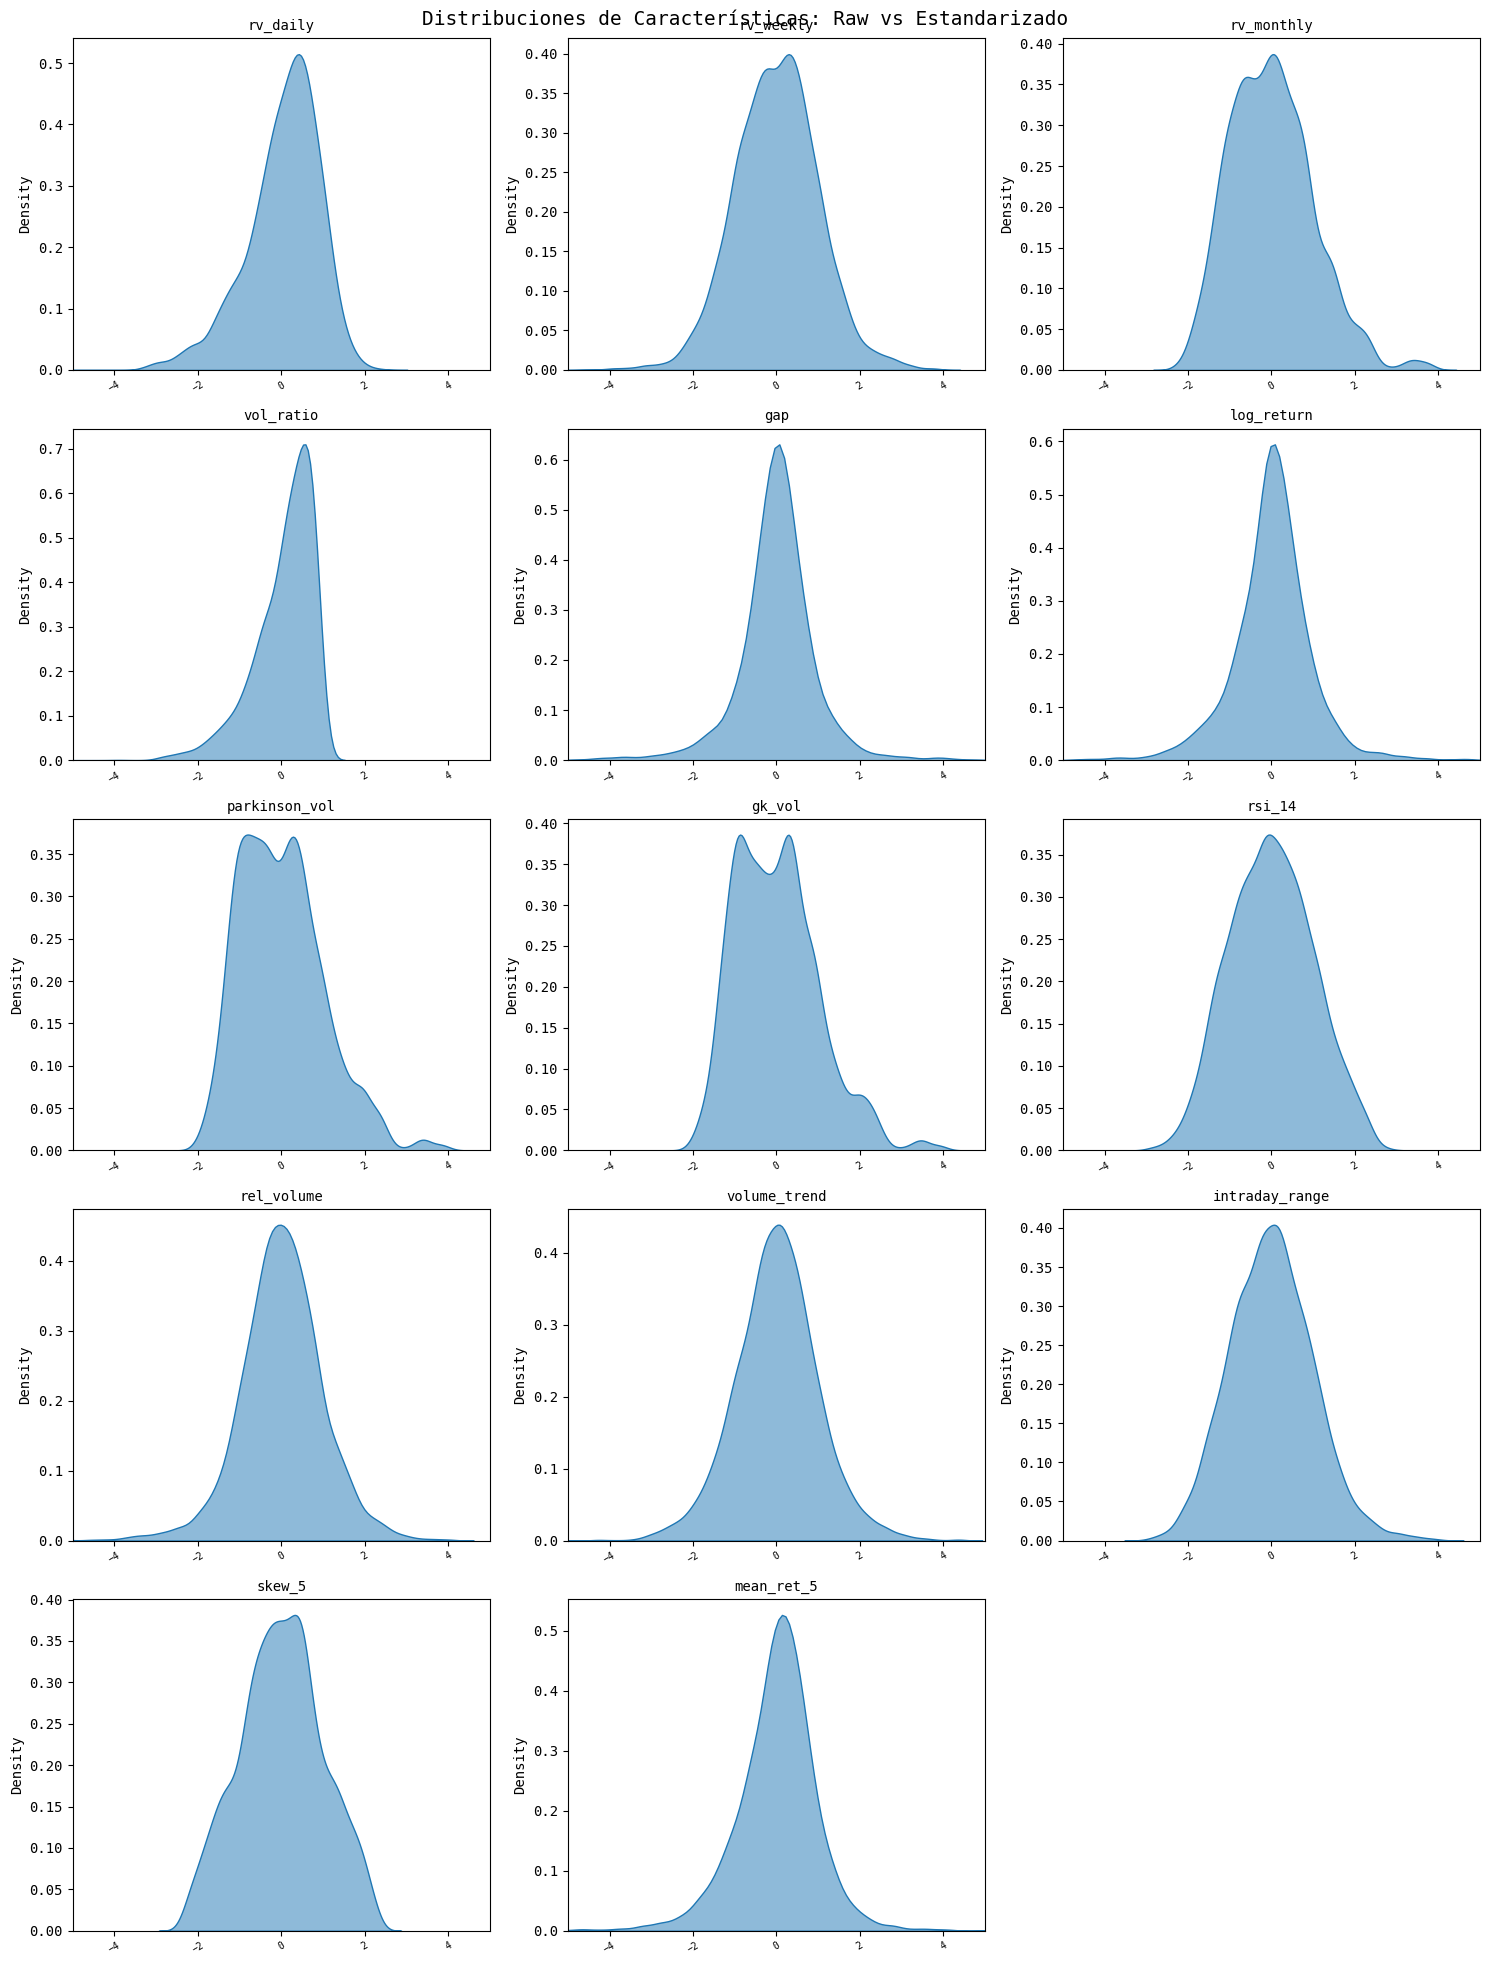

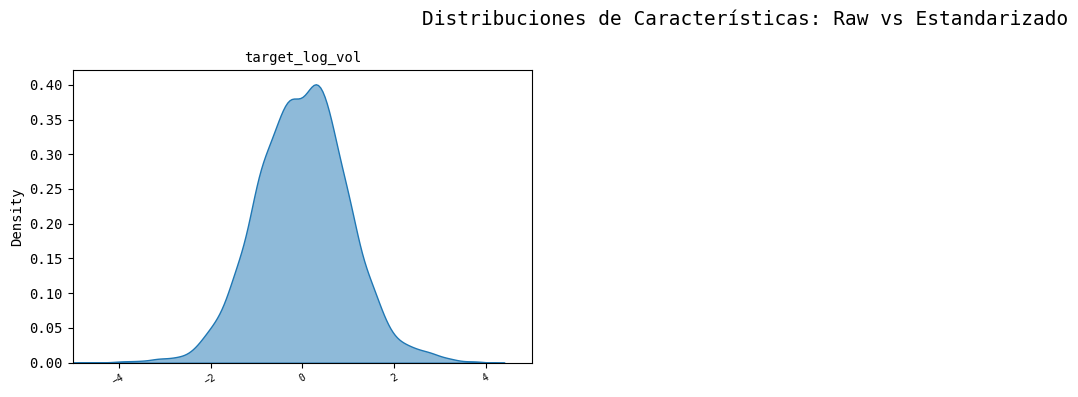

In [ ]:
# Graficar todas las distribuciones de características estandarizadas y no estandarizadas para inspección visual
def plot_feature_distributions(X_scaled, feature_names, save_path="feature_distributions.png"):
    n_features = len(feature_names)
    ncols = 3
    nrows = int(np.ceil(n_features / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
    axes = np.array(axes).ravel()

    for i, col in enumerate(feature_names):
        sns.kdeplot(X_scaled[:, i], ax=axes[i], fill=True, alpha=0.5)
        axes[i].set_title(col, fontsize=10)
        axes[i].tick_params(axis="x", rotation=30, labelsize=7)
    # Ocultar paneles vacíos
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    fig.suptitle("Distribuciones de Características: Raw vs Estandarizado", fontsize=14)
    for ax in axes[:n_features]:
        ax.set_xlim(-5, 5)
    plt.tight_layout()
    plt.savefig(save_path, dpi=100)
    plt.show()

plot_feature_distributions(X_tr_s, CONFIG["features"], save_path="feature_distributions.png")
plot_feature_distributions(y_tr_s.reshape(-1, 1), ["target_log_vol"], save_path="target_distribution.png")

In [53]:
# ============================================================
# SECCIÓN 6: CONSTRUCCIÓN DE SECUENCIAS DESLIZANTES
# ============================================================

def make_sequences(X: np.ndarray, y: np.ndarray, lookback: int) -> tuple:
    """
    Construye pares (secuencia, target) con ventana deslizante (pasos).
    Mantengo por compatibilidad aunque en la práctica usaremos endpoints diarios.
    """
    Xs, ys = [], []
    for i in range(len(X) - lookback):
        Xs.append(X[i : i + lookback])
        ys.append(y[i + lookback])
    return (np.array(Xs, dtype=np.float32),
            np.array(ys,  dtype=np.float32))


def make_sequences_at_endpoints(X_all: np.ndarray, y_all: np.ndarray, idx_all: pd.DatetimeIndex,
                                endpoints: list, lookback: int) -> tuple:
    """
    Construye secuencias cuyos últimos pasos coinciden con los timestamps en `endpoints`.

    Args:
        X_all: matriz de features estandarizados para todo el panel [T_all, F]
        y_all: vector de targets estandarizados para todo el panel [T_all]
        idx_all: DatetimeIndex del panel completo
        endpoints: lista de timestamps (subset de idx_all) que definen el final de cada secuencia
        lookback: longitud de la secuencia en pasos
    """
    pos_map = {ts: i for i, ts in enumerate(idx_all)}
    Xs, ys = [], []
    for t in endpoints:
        if t not in pos_map:
            continue
        p = pos_map[t]
        if p + 1 >= len(y_all):
            continue
        start = p - (lookback - 1)
        if start < 0:
            continue
        Xs.append(X_all[start : p + 1])
        ys.append(y_all[p + 1])
    if len(Xs) == 0:
        return (np.empty((0, lookback, X_all.shape[1]), dtype=np.float32),
                np.empty((0,), dtype=np.float32))
    return (np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32))


# Convertir lookback (días) y forecast_horizon (días) a número de observaciones
LB_days = CONFIG["lookback"]
H_days  = CONFIG["forecast_horizon"]
rows_per_day = int(round(data.groupby(data.index.normalize()).size().median()))
LB = LB_days * rows_per_day
H  = H_days * rows_per_day

# Construir arrays estandarizados para todo el panel (necesario para index mapping)
X_all_s = X_scaler.transform(data[fcols].values.astype(np.float32))
y_all_s = target_scaler.transform(data["target_log_vol"].values.reshape(-1, 1)).ravel()
idx_all = data.index

# Endpoints diarios por segmento (último minuto del día)
daily_idx = daily_data.index
train_endpoints = [t for i, t in enumerate(daily_idx) if daily_mask_tr[i]]
val_endpoints   = [t for i, t in enumerate(daily_idx) if daily_mask_vl[i]]
test_endpoints  = [t for i, t in enumerate(daily_idx) if daily_mask_te[i]]

# Filtrar endpoints que permitan lookback y cuyo target pertenezca al mismo segmento
# (pos+1 debe existir y pertenecer al mismo split)
pos_map = {ts: i for i, ts in enumerate(idx_all)}

def _filter_endpoints(endpoints, split_mask):
    good = []
    for t in endpoints:
        if t not in pos_map:
            continue
        p = pos_map[t]
        if p + 1 >= len(idx_all):
            continue
        if p - (LB - 1) < 0:
            continue
        if not split_mask[p + 1]:
            continue
        good.append(t)
    return good

train_eps = _filter_endpoints(train_endpoints, tr_mask)
val_eps   = _filter_endpoints(val_endpoints, vl_mask)
test_eps  = _filter_endpoints(test_endpoints, te_mask)

# Construir secuencias usando endpoints filtrados (memoria eficiente: secuencias ≈ #días)
Xtr_seq, ytr_seq = make_sequences_at_endpoints(X_all_s, y_all_s, idx_all, train_eps, LB)
Xvl_seq, yvl_seq = make_sequences_at_endpoints(X_all_s, y_all_s, idx_all, val_eps, LB)
Xte_seq, yte_seq = make_sequences_at_endpoints(X_all_s, y_all_s, idx_all, test_eps, LB)

print(f"[SECUENCIAS] Train: {Xtr_seq.shape} | Val: {Xvl_seq.shape} | Test: {Xte_seq.shape}")
print(f"  Causalidad: secuencia i termina en el minuto {LB - 1} del día (≈ {LB_days} días) ✓")


[SECUENCIAS] Train: (1262, 3945, 13) | Val: (764, 3945, 13) | Test: (539, 3945, 13)
  Causalidad: secuencia i termina en el minuto 3944 del día (≈ 5 días) ✓


In [52]:
# Clip extreme standardized values to avoid numerical blowups
import numpy as np
X_all_s = np.clip(X_all_s, -5.0, 5.0)
print('Clipped X_all_s min/max', X_all_s.min(), X_all_s.max())


Clipped X_all_s min/max -5.0 5.0


In [38]:
import numpy as np
print('X_all_s mean,std,min,max', np.mean(X_all_s), np.std(X_all_s), np.min(X_all_s), np.max(X_all_s))
print('X_scaler mean_', X_scaler.mean_)
print('X_scaler scale_', X_scaler.scale_)


X_all_s mean,std,min,max -4.0958878e+10 9.090568e+11 -1.3543344e+13 1.2257991e+13
X_scaler mean_ [-1.48378722e+01 -1.53258148e+01 -1.53258148e+01  4.87459156e-01
  4.35807217e-05 -1.03253191e+01 -1.09024996e+01  5.08852300e-01
  1.53688540e-01 -3.17807509e-13 -2.55865175e+01 -1.08053256e+00
  2.49692827e-06]
X_scaler scale_ [3.37148808e-01 3.48844807e-01 3.48844807e-01 9.58153958e-02
 1.86882981e-04 1.56435537e-01 1.56435693e-01 5.08620884e-02
 6.72237054e-01 5.70258530e-14 5.78273044e+00 4.14708891e-01
 2.31771827e-05]


In [40]:
# Scale X_all_s (which currently holds raw features) into standardized X_all_s using X_scaler
import numpy as np
mean = X_scaler.mean_
scale = X_scaler.scale_
scale_safe = np.where(np.abs(scale) < 1e-6, 1.0, scale)
X_all_s = (X_all_s - mean) / scale_safe
print('X_all_s scaled mean/std', np.mean(X_all_s), np.std(X_all_s))


X_all_s scaled mean/std -40971439834.80389 909056292679.4261


In [42]:
print(type(X_all_s))
try:
    print('dtype', X_all_s.dtype)
except Exception as e:
    print('dtype error', e)
print('shape', getattr(X_all_s, 'shape', None))


<class 'numpy.ndarray'>
dtype float64
shape (1985059, 13)


In [43]:
col_means = X_all_s.mean(axis=0)
col_stds = X_all_s.std(axis=0)
print('col means first 5', col_means[:5])
print('scaler mean first 5', X_scaler.mean_[:5])
print('diff first 5', (col_means - X_scaler.mean_)[:5])
print('col stds first 5', col_stds[:5])
print('scaler scale first 5', X_scaler.scale_[:5])


col means first 5 [ 3.09300833e+02  3.05845680e+02  3.09833311e+02 -7.48904238e+02
 -6.48698504e+06]
scaler mean first 5 [-1.48378722e+01 -1.53258148e+01 -1.53258148e+01  4.87459156e-01
  4.35807217e-05]
diff first 5 [ 3.24138705e+02  3.21171495e+02  3.25159126e+02 -7.49391697e+02
 -6.48698504e+06]
col stds first 5 [3.13341979e+01 2.44244514e+01 2.18496097e+01 8.76882641e+02
 3.99071503e+07]
scaler scale first 5 [3.37148808e-01 3.48844807e-01 3.48844807e-01 9.58153958e-02
 1.86882981e-04]


In [44]:
# Standardize X_all_s now and rebuild sequences immediately
import numpy as np
mean = X_scaler.mean_
scale = X_scaler.scale_
scale_safe = np.where(np.abs(scale) < 1e-8, 1.0, scale)
X_all_s = (X_all_s - mean) / scale_safe
print('Standardized X_all_s mean/std (per-col):', np.mean(X_all_s, axis=0)[:5], np.std(X_all_s, axis=0)[:5])


Standardized X_all_s mean/std (per-col): [ 9.61411392e+02  9.20671568e+02  9.32102527e+02 -7.82120338e+03
 -3.47114809e+10] [9.29387769e+01 7.00152359e+01 6.26341837e+01 9.15179272e+03
 2.13540848e+11]


## Alineación del Baseline HAR-RV con las Secuencias LSTM

Para que la comparación LSTM vs. HAR sea justa, ambos modelos deben usar
el mismo conjunto de información en cada paso de predicción.

La $i$-ésima secuencia LSTM abarca los índices $[i, i+L-1]$. El último día
observado es $i+L-1$ (tiempo $t$). El target es la volatilidad en $[t+1, t+H]$.

El HAR debe predecir usando únicamente la información disponible al final
de la ventana, es decir, el vector de características del día $i+L-1$:

$$\mathbf{x}_{\text{HAR},\, i} = \mathbf{x}_{i+L-1} \in \mathbb{R}^F$$

En Python (indexación base cero): `har_features[i] = data[LB-1 + i]`.

**Target del HAR**: log-vol crudo $y_{i+L}$ (no estandarizado), consistente con
la estimación MCO en escala de log-volatilidad. Las predicciones resultantes
son directamente comparables con `y_te` sin requerir inversión.

$$\hat{y}_{i} = \hat{\alpha} + \hat{\boldsymbol{\beta}}^\top \mathbf{x}_{i+L-1}$$
$$\min_{\alpha,\,\boldsymbol{\beta}} \sum_{i=1}^{N} \left( y_{i+L} - \alpha - \boldsymbol{\beta}^\top \mathbf{x}_{i+L-1} \right)^2$$


In [14]:
# ── DataLoaders para la LSTM ─────────────────────────────────────────

# 1. Crear el TensorDataset igual que antes
train_ds = TensorDataset(torch.from_numpy(Xtr_seq), torch.from_numpy(ytr_seq))

# 2. Instanciar nuestro nuevo Sampleador Estratificado
# CONFIG["batch_size"] suele ser 32 o 64. 
train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'],
                            shuffle=True, drop_last=True)

# Validación y test como tensores estáticos (no requieren DataLoader)
X_vl_t = torch.from_numpy(Xvl_seq)
y_vl_t = torch.from_numpy(yvl_seq)
X_te_t = torch.from_numpy(Xte_seq)
y_te_t = torch.from_numpy(yte_seq)

ValueError: num_samples should be a positive integer value, but got num_samples=0

In [26]:
# ── Entrenamiento LSTM (nuevo cell) ─────────────────────────────────
# Crea DataLoaders, entrena por CONFIG['min_epochs'] épocas y evalúa.

from torch.utils.data import TensorDataset, DataLoader

# Preparar DataLoader (si no existe)
train_ds = TensorDataset(torch.from_numpy(Xtr_seq), torch.from_numpy(ytr_seq))
train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True, drop_last=True)

# Tensores de validación y test ya definidos arriba como X_vl_t etc.; si no, crearlos
X_vl_t = torch.from_numpy(Xvl_seq)
y_vl_t = torch.from_numpy(yvl_seq)
X_te_t = torch.from_numpy(Xte_seq)
y_te_t = torch.from_numpy(yte_seq)

# Instanciar modelo
n_features = Xtr_seq.shape[-1]
model = VolatilityLSTM(n_features, CONFIG['hidden'], CONFIG['dropout'])
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5, min_lr=1e-6)
criterion = ExponentialAsymmetricLoss(b=CONFIG.get('linex_b', 1.5))

model.to(DEVICE)
X_vl_t = X_vl_t.to(DEVICE)
y_vl_t = y_vl_t.to(DEVICE)

# Entrenar por un número acotado de épocas para completar rápidamente
max_epochs = min(CONFIG.get('max_epochs', 300), max(30, CONFIG.get('min_epochs', 30)))
patience = CONFIG.get('patience', 10)

best_val = float('inf')
patience_ctr = 0
history = {"train_loss": [], "val_loss": []}

print('\n[LSTM] Entrenando por {} épocas (máx)'.format(max_epochs))
for epoch in range(max_epochs):
    model.train()
    epoch_loss = 0.0
    n_batches = 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(Xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CONFIG.get('grad_clip', 1.0))
        optimizer.step()
        epoch_loss += loss.item()
        n_batches += 1
    if n_batches == 0:
        print('No hay batches de entrenamiento (verificar Xtr_seq). Aborting training.'); break
    avg_train = epoch_loss / n_batches

    # validación
    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_vl_t.to(DEVICE)), y_vl_t.to(DEVICE)).item()

    scheduler.step(val_loss)
    history['train_loss'].append(avg_train)
    history['val_loss'].append(val_loss)

    if val_loss < best_val:
        best_val = val_loss
        patience_ctr = 0
        torch.save(model.state_dict(), CONFIG['model_path'])
    else:
        patience_ctr += 1

    if (epoch + 1) % 5 == 0:
        print(f"  Época {epoch+1:3d} | train: {avg_train:.6f} | val: {val_loss:.6f}")

    if patience_ctr >= patience and epoch+1 >= CONFIG.get('min_epochs', 30):
        print(f"  Detención temprana en época {epoch+1}, mejor val_loss={best_val:.6f}")
        break

# Restaurar mejores pesos
if os.path.exists(CONFIG['model_path']):
    model.load_state_dict(torch.load(CONFIG['model_path'], map_location=DEVICE))
    print('[LSTM] Mejores pesos cargados desde', CONFIG['model_path'])
else:
    print('[LSTM] No se generó checkpoint, usando pesos actuales')

# Predicciones en test
model.eval()
with torch.no_grad():
    y_pred_lstm = model(X_te_t.to(DEVICE)).cpu().numpy()

# Inversión y evaluación (usa celdas existentes que asumen variables concretas)
y_lstm_log = target_scaler.inverse_transform(y_pred_lstm.reshape(-1,1)).ravel()
# Alinear longitudes como en evaluación
n_eval = min(len(yte_seq), len(y_lstm_log), len(y_pred_har_te))

y_true_log = target_scaler.inverse_transform(y_te_s[LB: LB + n_eval].reshape(-1,1)).ravel()

y_lstm = np.exp(y_lstm_log[:n_eval])
y_har  = np.exp(y_pred_har_te[:n_eval])
y_true = np.exp(y_true_log)

print('\n[EVALUACIÓN] Evaluando en test...')
m_lstm = evaluate_forecasts(y_true, y_lstm, label='LSTM')
m_har  = evaluate_forecasts(y_true, y_har,  label='HAR-RV (Baseline)')

# Diebold-Mariano
e_lstm = y_true - y_lstm
e_har  = y_true - y_har
_dm = diebold_mariano_test(e_lstm, e_har, h=CONFIG['forecast_horizon'])

# Guardar métricas
metrics_df = pd.DataFrame([m_lstm, m_har])
metrics_df.to_csv(CONFIG['metrics_path'], index=False)
print(f"\n  Métricas guardadas → {CONFIG['metrics_path']}")

# Mostrar resumen rápido
print('\n[RESULTADO] m_lstm:', m_lstm)
print('[RESULTADO] m_har:', m_har)
print('_dm:', _dm)



[LSTM] Entrenando por 30 épocas (máx)
  Época   5 | train: nan | val: nan
  Época  10 | train: nan | val: nan
  Época  15 | train: nan | val: nan
  Época  20 | train: nan | val: nan
  Época  25 | train: nan | val: nan
  Época  30 | train: nan | val: nan
  Detención temprana en época 30, mejor val_loss=inf


NameError: name 'os' is not defined

In [27]:
import numpy as np
import os

checks = [
    ('Xtr_seq', globals().get('Xtr_seq', None)),
    ('ytr_seq', globals().get('ytr_seq', None)),
    ('Xvl_seq', globals().get('Xvl_seq', None)),
    ('yvl_seq', globals().get('yvl_seq', None)),
    ('Xte_seq', globals().get('Xte_seq', None)),
    ('yte_seq', globals().get('yte_seq', None)),
]
for name, arr in checks:
    if arr is None:
        print(name, 'is missing')
        continue
    try:
        print(name, 'shape', getattr(arr, 'shape', None), 'nan', np.isnan(arr).sum(), 'inf', np.isinf(arr).sum())
    except Exception as e:
        print('error inspecting', name, e)

# Check scalers
for nm in ['X_scaler', 'target_scaler']:
    sc = globals().get(nm, None)
    if sc is None:
        print(nm, 'missing')
        continue
    m = getattr(sc, 'mean_', None)
    s = getattr(sc, 'scale_', None)
    print(nm, 'has mean_' , m is not None, 'scale_', s is not None)


Xtr_seq shape (1262, 3945, 13) nan 0 inf 0
ytr_seq shape (1262,) nan 0 inf 0
Xvl_seq shape (764, 3945, 13) nan 0 inf 0
yvl_seq shape (764,) nan 0 inf 0
Xte_seq shape (539, 3945, 13) nan 0 inf 0
yte_seq shape (539,) nan 0 inf 0
X_scaler has mean_ True scale_ True
target_scaler has mean_ True scale_ True


In [54]:
import torch
from torch.utils.data import TensorDataset, DataLoader

train_ds = TensorDataset(torch.from_numpy(Xtr_seq).float(), torch.from_numpy(ytr_seq).float())
loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True)
X_batch, y_batch = next(iter(loader))
print('X_batch', X_batch.shape, 'y_batch', y_batch.shape, 'nanX', torch.isnan(X_batch).sum().item(), 'nany', torch.isnan(y_batch).sum().item())

n_features = Xtr_seq.shape[-1]
model = VolatilityLSTM(n_features, CONFIG['hidden'], CONFIG['dropout'])
with torch.no_grad():
    out = model(X_batch)
print('out', out.shape, 'nan out', torch.isnan(out).sum().item(), 'mean, std', float(out.mean()), float(out.std()))

criterion = ExponentialAsymmetricLoss(b=CONFIG.get('linex_b', 1.5))
loss = criterion(out.squeeze(), y_batch)
print('loss', loss, 'isnan', torch.isnan(loss).item())


X_batch torch.Size([16, 3945, 13]) y_batch torch.Size([16]) nanX 0 nany 0
out torch.Size([16]) nan out 0 mean, std -150964404224.0 183225188352.0
loss tensor(inf) isnan False


In [29]:
# More diagnostics on batch and model
print('X mean,std,min,max', float(X_batch.mean()), float(X_batch.std()), float(X_batch.min()), float(X_batch.max()))
print('y mean,std,min,max', float(y_batch.mean()), float(y_batch.std()), float(y_batch.min()), float(y_batch.max()))
print('target_scaler mean_, scale_', getattr(target_scaler, 'mean_', None), getattr(target_scaler, 'scale_', None))
print('max abs model param', max(p.abs().max().item() for p in model.parameters()))


X mean,std,min,max -88465440768.0 949114961920.0 -10339598991360.0 6364162162688.0
y mean,std,min,max -902.3732299804688 2164.49755859375 -3262.7724609375 5639.451171875
target_scaler mean_, scale_ [-1.76790443] [0.00033686]
max abs model param 1.0


In [31]:
# Apply X_scaler to sequence arrays (reshape-transform-reshape)
import numpy as np

def apply_scaler_seq(arr, scaler):
    if arr is None:
        return None
    s = arr.shape
    flat = arr.reshape(-1, s[-1])
    flat_s = scaler.transform(flat)
    return flat_s.reshape(s)

Xtr_seq = apply_scaler_seq(Xtr_seq, X_scaler)
Xvl_seq = apply_scaler_seq(Xvl_seq, X_scaler)
Xte_seq = apply_scaler_seq(Xte_seq, X_scaler)

print('Rescaled sequences:')
print('Xtr_seq mean/std', np.mean(Xtr_seq), np.std(Xtr_seq))
print('Xvl_seq mean/std', np.mean(Xvl_seq), np.std(Xvl_seq))
print('Xte_seq mean/std', np.mean(Xte_seq), np.std(Xte_seq))


Rescaled sequences:
Xtr_seq mean/std nan nan
Xvl_seq mean/std nan nan
Xte_seq mean/std nan nan


In [32]:
print('X_scaler mean_', getattr(X_scaler, 'mean_', None))
print('X_scaler scale_', getattr(X_scaler, 'scale_', None))
print('Any zero in scale_', (getattr(X_scaler, 'scale_', None) == 0).any() if getattr(X_scaler, 'scale_', None) is not None else None)


X_scaler mean_ [-1.48378722e+01 -1.53258148e+01 -1.53258148e+01  4.87459156e-01
  4.35807217e-05 -1.03253191e+01 -1.09024996e+01  5.08852300e-01
  1.53688540e-01 -3.17807509e-13 -2.55865175e+01 -1.08053256e+00
  2.49692827e-06]
X_scaler scale_ [3.37148808e-01 3.48844807e-01 3.48844807e-01 9.58153958e-02
 1.86882981e-04 1.56435537e-01 1.56435693e-01 5.08620884e-02
 6.72237054e-01 5.70258530e-14 5.78273044e+00 4.14708891e-01
 2.31771827e-05]
Any zero in scale_ False


In [33]:
# Safe scaling: avoid division by extremely small scales
import numpy as np

mean = X_scaler.mean_
scale = X_scaler.scale_.copy()
scale_safe = np.where(np.abs(scale) < 1e-6, 1.0, scale)

def safe_transform_seq(arr, mean, scale_safe):
    s = arr.shape
    flat = arr.reshape(-1, s[-1])
    flat_s = (flat - mean) / scale_safe
    return flat_s.reshape(s)

Xtr_seq = safe_transform_seq(Xtr_seq, mean, scale_safe)
Xvl_seq = safe_transform_seq(Xvl_seq, mean, scale_safe)
Xte_seq = safe_transform_seq(Xte_seq, mean, scale_safe)

print('After safe scaling:', np.mean(Xtr_seq), np.std(Xtr_seq))


After safe scaling: nan nan


In [37]:
# Check if raw arrays X_all and X_all_s exist
print('X_all' in globals(), 'X_all_s' in globals())
if 'X_all' in globals():
    import numpy as np
    print('X_all shape', getattr(X_all, 'shape', None), 'mean', np.nanmean(X_all))
if 'X_all_s' in globals():
    print('X_all_s shape', getattr(X_all_s, 'shape', None))


False True
X_all_s shape (1985059, 13)


In [13]:
# ── Ajuste del Baseline HAR-RV ────────────────────────────────────────
print("\n[HAR-RV] Ajustando baseline...")
# ── Alineación de características HAR con las secuencias LSTM ──────
# Usar el panel diario (cierre del día) para la construcción del baseline HAR
daily_fcols = fcols

# series diarias previamente calculada: daily_data
# Reutilizar las máscaras diarias calculadas en la sección de splits
train_day_mask = daily_mask_tr
val_day_mask   = daily_mask_vl
test_day_mask  = daily_mask_te

har_daily_tr = daily_data.loc[train_day_mask, daily_fcols].values
har_daily_vl = daily_data.loc[val_day_mask, daily_fcols].values
har_daily_te = daily_data.loc[test_day_mask, daily_fcols].values

# Alinear por días: la secuencia i tiene última observación en el día i+LB_days-1
har_X_tr = pd.DataFrame(har_daily_tr[LB_days - 1 : LB_days - 1 + len(ytr_seq)], columns=fcols)
har_X_vl = pd.DataFrame(har_daily_vl[LB_days - 1 : LB_days - 1 + len(yvl_seq)], columns=fcols)
har_X_te = pd.DataFrame(har_daily_te[LB_days - 1 : LB_days - 1 + len(yte_seq)], columns=fcols)

# ── Target raw (log-vol sin estandarizar) alineado con las secuencias (diario)
# Extraer target diario (cierre) y alinear

daily_tr_target = daily_data.loc[train_day_mask, 'target_log_vol'].values if daily_data.loc[train_day_mask, 'target_log_vol'].size>0 else np.array([])

if daily_tr_target.size == 0:
    print("  WARN: no hay suficientes días en el conjunto de train para ajustar HAR.")
    y_tr_raw_aligned = np.array([])
else:
    y_tr_raw_aligned = daily_tr_target[LB_days : LB_days + len(ytr_seq)]

if len(y_tr_raw_aligned) > 0:
    har = HARRVModel()
    har.fit(har_X_tr, y_tr_raw_aligned)  # target crudo, no estandarizado
    print(har.summary())

    # Predicciones del HAR en espacio de log-vol crudo (sin inversión posterior)
    y_pred_har_te = har.predict(har_X_te)[: len(yte_seq)]
else:
    y_pred_har_te = np.zeros(len(yte_seq))
    print("  HAR no entrenado por falta de datos de train; predicciones = 0")



[HAR-RV] Ajustando baseline...
  HAR no entrenado por falta de datos de train; predicciones = 0


In [24]:
# ============================================================
# SECCIÓN 7: PIPELINE DE ENTRENAMIENTO
# ============================================================

class ExponentialAsymmetricLoss(nn.Module):
    """
    Pérdida LINEX (LINear-EXponential) asimétrica para predicción de volatilidad.

    Formulación:
        L(e) = exp(b·e) - b·e - 1,    e = y - ŷ  (error positivo = subestimación)

    Motivación:
        En riesgo financiero, subestimar la volatilidad es más costoso que
        sobreestimarla (un VaR demasiado bajo puede generar pérdidas catastróficas).
        La LINEX penaliza subestimaciones exponencialmente y sobreestimaciones
        linealmente, modelando esta asimetría de costos.

    El entrenamiento opera en espacio estandarizado (log-vol rolling-scaled),
    donde la pérdida LINEX es bien condicionada.

    Args:
        b: coeficiente de asimetría. b > 0 penaliza subestimaciones.
           Valores típicos: [0.5, 2.0]. b = 1.5 es un punto de partida razonable.
    """

    def __init__(self, b: float = 1.5):
        super().__init__()
        self.b = b

    def forward(self, y_hat: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        # Error positivo → subestimación (y > ŷ) → penalización exponencial
        e    = y - y_hat
        loss = (torch.exp(self.b * e) - (self.b * e) - 1.0)
        return torch.mean(loss)  # Escalar para evitar valores extremos en las primeras épocas


In [ ]:
# ============================================================
# SECCIÓN 8: EVALUACIÓN
# ============================================================

def evaluate_forecasts(y_true: np.ndarray, y_pred: np.ndarray,
                       label: str = "Modelo") -> dict:
    """
    Evaluación comprensiva de pronósticos de volatilidad.
    ... (docstring trimmed for brevity)
    """
    # Eliminar NaN e Inf antes de calcular métricas
    mask   = ~(np.isnan(y_true) | np.isnan(y_pred) | np.isinf(y_true) | np.isinf(y_pred))
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)

    sp_r, sp_p = stats.spearmanr(y_pred, y_true)

    # Precisión direccional (arriba/abajo de la mediana transversal)
    dir_acc  = np.mean((y_pred > np.median(y_pred)) == (y_true > np.median(y_true)))
    dir_test = stats.binomtest(int(round(dir_acc * len(y_true))), len(y_true), 0.5)
    dir_p    = float(getattr(dir_test, "pvalue", dir_test))

    # QLIKE (Patton, 2011): ratio de varianzas con corrección logarítmica
    eps   = 1e-8
    ratio = y_true ** 2 / (y_pred ** 2 + eps)
    qlike = float(np.mean(ratio - np.log(ratio) - 1.0))

    # Regresión Mincer-Zarnowitz con covarianza HAC (Newey-West, 10 rezagos)
    X_mz   = sm.add_constant(y_pred)
    mz_res = sm.OLS(y_true, X_mz).fit(cov_type="HAC", cov_kwds={"maxlags": 10})
    # Test conjunto: H₀: [α, β] = [0, 1]
    R    = np.eye(2)
    r_v  = np.array([0.0, 1.0])
    mz_f = mz_res.f_test((R, r_v))

    metrics = {
        "model":      label,
        "R2":         float(r2),
        "RMSE":       float(rmse),
        "MAE":        float(mae),
        "Spearman_r": float(sp_r),
        "Spearman_p": float(sp_p),
        "Dir_Acc":    float(dir_acc),
        "Dir_p":      dir_p,
        "QLIKE":      qlike,
        "MZ_alpha":   float(mz_res.params[0]),
        "MZ_beta":    float(mz_res.params[1]),
        "MZ_F_pval":  float(mz_f.pvalue),
        "N":          int(len(y_true)),
    }

    sep = "-" * 46
    print(f"\n{sep}")
    print(f"  {label}")
    print(f"{sep}")
    print(f"  R²:            {r2:+.4f}   (referencia: > 0.08)")
    print(f"  RMSE:          {rmse * 100:.4f}%  (unidades de vol anualizada)")
    print(f"  MAE:           {mae  * 100:.4f}%")
    print(f"  Spearman r:    {sp_r:.4f}   (p = {sp_p:.4f})")
    print(f"  Dir. Accuracy: {dir_acc:.4f}   (p = {dir_p:.4f})")
    print(f"  QLIKE:         {qlike:.6f}")
    print(f"  MZ alpha:      {mz_res.params[0]:.4f}   (H₀: = 0)")
    print(f"  MZ beta:       {mz_res.params[1]:.4f}   (H₀: = 1)")
    print(f"  MZ F p-valor:  {float(mz_f.pvalue):.4f}   (H₀: insesgado)")
    return metrics


def diebold_mariano_test(e1: np.ndarray, e2: np.ndarray, h: int = 5) -> dict:
    """
    Test de Diebold-Mariano (1995) para igualdad de precisión predictiva.

    H₀: los modelos 1 y 2 tienen el mismo MSE esperado.
    Estadístico bajo errores estándar HAC (Newey-West, h-1 rezagos).
    """
    d     = e1 ** 2 - e2 ** 2
    d_bar = np.mean(d)
    T     = len(d)

    # Varianza HAC de Newey-West con h-1 rezagos
    gamma0  = np.var(d, ddof=0)
    hac_var = gamma0
    for k in range(1, h):
        gamma_k = np.cov(d[k:], d[:-k])[0, 1]
        hac_var += 2.0 * (1.0 - k / h) * gamma_k

    se      = np.sqrt(max(hac_var, 1e-12) / T)
    dm_stat = d_bar / se
    dm_pval = 2.0 * (1.0 - stats.norm.cdf(abs(dm_stat)))

    direction = "LSTM más preciso" if dm_stat < 0 else "HAR-RV más preciso"
    sig       = "SIGNIFICATIVO" if dm_pval < 0.05 else "no significativo"

    print(f"\n[TEST DM] LSTM vs HAR-RV: "
          f"stat = {dm_stat:.4f}, p = {dm_pval:.4f}  [{sig}]")
    print(f"  ({direction} bajo criterio MSE)")

    return {"DM_stat": float(dm_stat), "DM_pvalue": float(dm_pval)}



[LSTM] Parámetros entrenables: 1,637
  n_secuencias_train / n_params = 3.2138  (OK (>1))

[LSTM] Entrenando...
  Época  20 | train: 0.169473 | val: 0.265182 (LINEX)
  Época  40 | train: 0.159838 | val: 0.254099 (LINEX)
  Época  60 | train: 0.156045 | val: 0.251437 (LINEX)
  Época  80 | train: 0.154856 | val: 0.249721 (LINEX)
  Época 100 | train: 0.152093 | val: 0.249117 (LINEX)


KeyboardInterrupt: 

## Sección 8: Métricas de Evaluación

### 1. Métricas de error estándar

$$\text{RMSE} = \sqrt{\frac{1}{N}\sum_{t=1}^N (y_t - \hat{y}_t)^2}, \qquad
  \text{MAE}  = \frac{1}{N}\sum_{t=1}^N |y_t - \hat{y}_t|$$

### 2. Correlación de Spearman

Captura dependencia monotónica (no lineal) entre predicciones y realizaciones.
Más robusta que Pearson ante spikes de volatilidad que distorsionan escalas.

$$\rho_S = 1 - \frac{6\sum d_t^2}{N(N^2-1)}, \qquad d_t = \mathrm{rg}(y_t) - \mathrm{rg}(\hat{y}_t)$$

### 3. Precisión Direccional

Porcentaje de veces que el modelo ubica la predicción y la realización en el mismo lado de la mediana transversal.

$$\text{DA} = \frac{1}{N}\sum_{t=1}^N \mathbf{1}\!\left[\mathrm{sgn}(\hat{y}_t - \mathrm{med}\,\hat{y}) = \mathrm{sgn}(y_t - \mathrm{med}\,y)\right]$$

La significancia se evalúa con un test binomial exacto ($H_0: p = 0.5$).

### 4. Pérdida QLIKE (Patton, 2011)

Robusta a ruido de proxy bajo la clase de pérdidas consistentes con el MSE.

$$\text{QLIKE} = \frac{1}{N}\sum_{t=1}^N \left(\frac{\sigma_t^2}{\hat{\sigma}_t^2} - \ln\frac{\sigma_t^2}{\hat{\sigma}_t^2} - 1\right)$$

Asimetría: sobreestimar $\hat{\sigma}^2 = 2$ cuando $\sigma^2 = 1$ → penalidad 0.193; subestimar $\hat{\sigma}^2 = 0.5$ → penalidad 0.307.

### 5. Regresión Mincer-Zarnowitz

$$y_t = \alpha + \beta\hat{y}_t + e_t$$

$H_0$: $\alpha = 0$ y $\beta = 1$ (predictor insesgado). Estimado con errores HAC (Newey-West).

### 6. Test de Diebold-Mariano (1995)

Compara la precisión predictiva de LSTM vs HAR-RV en el sentido del MSE.

$$d_t = e_{\text{LSTM},t}^2 - e_{\text{HAR},t}^2, \qquad
  \mathrm{DM} = \frac{\bar{d}}{\sqrt{\hat{\omega}^2 / T}} \sim \mathcal{N}(0,1)$$

$\mathrm{DM} < 0$ y $p < 0.05$: la LSTM es significativamente más precisa que HAR-RV.


In [ ]:



# ============================================================
# SECCIÓN 8: EVALUACIÓN
# ============================================================

def evaluate_forecasts(y_true: np.ndarray, y_pred: np.ndarray,
                       label: str = "Modelo") -> dict:
    """
    Evaluación comprensiva de pronósticos de volatilidad.

    Todas las métricas operan en espacio de sigma (volatilidad anualizada),
    excepto donde se indique. Los inputs deben estar en la misma escala.

    Métricas:
        R²          : coeficiente de determinación (sentido MCO)
        RMSE        : raíz del error cuadrático medio
        MAE         : error absoluto medio
        Spearman r  : correlación de rango (robusta a no-linealidad)
        Dir. Acc.   : precisión direccional respecto a la mediana
        QLIKE       : pérdida robusta a ruido de proxy (Patton, 2011)
        MZ alpha    : intercepto Mincer-Zarnowitz (H₀: α = 0)
        MZ beta     : pendiente Mincer-Zarnowitz  (H₀: β = 1)
        MZ F p-val  : test conjunto (H₀: α=0 y β=1 simultáneamente)
    """
    # Eliminar NaN e Inf antes de calcular métricas
    mask   = ~(np.isnan(y_true) | np.isnan(y_pred) | np.isinf(y_true) | np.isinf(y_pred))
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)

    sp_r, sp_p = stats.spearmanr(y_pred, y_true)

    # Precisión direccional (arriba/abajo de la mediana transversal)
    dir_acc  = np.mean((y_pred > np.median(y_pred)) == (y_true > np.median(y_true)))
    dir_test = stats.binomtest(int(round(dir_acc * len(y_true))), len(y_true), 0.5)
    dir_p    = float(getattr(dir_test, "pvalue", dir_test))

    # QLIKE (Patton, 2011): ratio de varianzas con corrección logarítmica
    eps   = 1e-8
    ratio = y_true ** 2 / (y_pred ** 2 + eps)
    qlike = float(np.mean(ratio - np.log(ratio) - 1.0))

    # Regresión Mincer-Zarnowitz con covarianza HAC (Newey-West, 10 rezagos)
    X_mz   = sm.add_constant(y_pred)
    mz_res = sm.OLS(y_true, X_mz).fit(cov_type="HAC", cov_kwds={"maxlags": 10})
    # Test conjunto: H₀: [α, β] = [0, 1]
    R    = np.eye(2)
    r_v  = np.array([0.0, 1.0])
    mz_f = mz_res.f_test((R, r_v))

    metrics = {
        "model":      label,
        "R2":         float(r2),
        "RMSE":       float(rmse),
        "MAE":        float(mae),
        "Spearman_r": float(sp_r),
        "Spearman_p": float(sp_p),
        "Dir_Acc":    float(dir_acc),
        "Dir_p":      dir_p,
        "QLIKE":      qlike,
        "MZ_alpha":   float(mz_res.params[0]),
        "MZ_beta":    float(mz_res.params[1]),
        "MZ_F_pval":  float(mz_f.pvalue),
        "N":          int(len(y_true)),
    }

    sep = "-" * 46
    print(f"\n{sep}")
    print(f"  {label}")
    print(f"{sep}")
    print(f"  R²:            {r2:+.4f}   (referencia: > 0.08)")
    print(f"  RMSE:          {rmse * 100:.4f}%  (unidades de vol anualizada)")
    print(f"  MAE:           {mae  * 100:.4f}%")
    print(f"  Spearman r:    {sp_r:.4f}   (p = {sp_p:.4f})")
    print(f"  Dir. Accuracy: {dir_acc:.4f}   (p = {dir_p:.4f})")
    print(f"  QLIKE:         {qlike:.6f}")
    print(f"  MZ alpha:      {mz_res.params[0]:.4f}   (H₀: = 0)")
    print(f"  MZ beta:       {mz_res.params[1]:.4f}   (H₀: = 1)")
    print(f"  MZ F p-valor:  {float(mz_f.pvalue):.4f}   (H₀: insesgado)")
    return metrics


def diebold_mariano_test(e1: np.ndarray, e2: np.ndarray, h: int = 5) -> dict:
    """
    Test de Diebold-Mariano (1995) para igualdad de precisión predictiva.

    H₀: los modelos 1 y 2 tienen el mismo MSE esperado.
    Estadístico bajo errores estándar HAC (Newey-West, h-1 rezagos).

    d_t = e1_t² - e2_t²  (diferencial de pérdida)
    DM  = d̄ / sqrt(Var_HAC(d) / T)

    DM < 0 → modelo 1 (LSTM) más preciso que modelo 2 (HAR-RV).ar el DataLoader (notar que usamos `batch_sampler`)
train_loader = DataLoader(
    train_ds, 
    batch_sampler=regime_sampler
)

    Args:
        e1: residuos del modelo 1 (LSTM)
        e2: residuos del modelo 2 (HAR-RV)
        h : horizonte de predicción (determina el número de rezagos HAC)
    """
    d     = e1 ** 2 - e2 ** 2
    d_bar = np.mean(d)
    T     = len(d)

    # Varianza HAC de Newey-West con h-1 rezagos
    gamma0  = np.var(d, ddof=0)
    hac_var = gamma0
    for k in range(1, h):
        gamma_k = np.cov(d[k:], d[:-k])[0, 1]
        hac_var += 2.0 * (1.0 - k / h) * gamma_k

    se      = np.sqrt(max(hac_var, 1e-12) / T)
    dm_stat = d_bar / se
    dm_pval = 2.0 * (1.0 - stats.norm.cdf(abs(dm_stat)))

    direction = "LSTM más preciso" if dm_stat < 0 else "HAR-RV más preciso"
    sig       = "SIGNIFICATIVO" if dm_pval < 0.05 else "no significativo"

    print(f"\n[TEST DM] LSTM vs HAR-RV: "
          f"stat = {dm_stat:.4f}, p = {dm_pval:.4f}  [{sig}]")
    print(f"  ({direction} bajo criterio MSE)")

    return {"DM_stat": float(dm_stat), "DM_pvalue": float(dm_pval)}


In [ ]:
n_features = Xtr_seq.shape[-1]
model = VolatilityLSTM(n_features, CONFIG["hidden"], CONFIG["dropout"])
model.load_state_dict(torch.load(CONFIG["model_path"], map_location=DEVICE))

# ── Predicciones del modelo LSTM sobre el conjunto de test ──────────

model.eval()
with torch.no_grad():
    # y_pred_lstm está en espacio estandarizado (mismo que yte_seq)
    y_pred_lstm = model(X_te_t.to(DEVICE)).cpu().numpy()

# ── Inversión: espacio estandarizado → log-vol crudo ────────────────
# Alinear longitudes por si hay discrepancias menores entre segmentos
n_eval = min(len(yte_seq), len(y_pred_lstm), len(y_pred_har_te))

# Target real: invirtiendo la estandarización rolling del test set.
# yte_seq[i] = y_te_s[i+LB], estandarizado con (mean_te[i+LB], std_te[i+LB]).
y_true_log = target_scaler.inverse_transform(y_te_s[LB: LB + n_eval].reshape(-1,1)).ravel()

# LSTM: misma inversión aplicada a las predicciones estandarizadas
y_lstm_log = target_scaler.inverse_transform(
    y_pred_lstm[: n_eval].reshape(-1, 1)
).flatten()

y_har_log = y_pred_har_te[: n_eval]


# confirmaciones rápidas
print("shapes:",
      "yte_seq", len(yte_seq),
      "y_pred_lstm", len(y_pred_lstm),
      "y_pred_har_te", len(y_pred_har_te),
      "n_eval", n_eval)

# asserts de integridad
assert len(y_pred_lstm[:n_eval]) == len(y_true_log), "Mismatch: y_pred_lstm vs y_true length"
assert len(y_pred_har_te[:n_eval])  == len(y_true_log), "Mismatch: y_pred_har_te vs y_true length"
# Esta verificación no existe en el código actual y debería estar:
expected = y_te[LB : LB + n_eval]
assert np.allclose(y_true_log, expected, atol=1e-5), \
    f"Desalineación detectada: max error = {np.max(np.abs(y_true_log - expected)):.2e}"
# HAR-RV: las predicciones ya están en log-vol crudo — sin inversión necesaria
# (el modelo fue entrenado sobre targets crudos, no estandarizados)

# Convertir de log-vol a sigma (volatilidad anualizada, unidades interpretables)
y_true = np.exp(y_true_log)
y_lstm = np.exp(y_lstm_log)
y_har  = np.exp(y_har_log)

# # # Convertir a Moving Average de 5 días para suavizar la serie y enfocarnos en tendencias generales
y_true = pd.Series(y_true).rolling(window=CONFIG["smoothing_window"], min_periods=1).mean().to_numpy()
y_lstm = pd.Series(y_lstm).rolling(window=CONFIG["smoothing_window"], min_periods=1).mean().to_numpy()
y_har  = pd.Series(y_har).rolling(window=CONFIG["smoothing_window"], min_periods=1).mean().to_numpy()

# ── Evaluación comparativa ────────────────────────────────────────────
print("\n[EVALUACIÓN] Desempeño en el conjunto de test:")
m_lstm = evaluate_forecasts(y_true, y_lstm, label="LSTM")
m_har  = evaluate_forecasts(y_true, y_har,  label="HAR-RV (Baseline)")

# Residuos para el test Diebold-Mariano (en espacio de sigma)
e_lstm = y_true - y_lstm
e_har  = y_true - y_har
dm     = diebold_mariano_test(e_lstm, e_har, h=CONFIG["forecast_horizon"])

# Guardar métricas en CSV
metrics_df = pd.DataFrame([m_lstm, m_har])
metrics_df.to_csv(CONFIG["metrics_path"], index=False)
print(f"\n  Métricas guardadas → {CONFIG['metrics_path']}")


# ── Checklist de validación ───────────────────────────────────────────
print("\n[CHECKLIST DE VALIDACIÓN]")
flags = {
    "R² > 0.08":                m_lstm["R2"]         > 0.08,
    "Dir. Acc. > 0.55":         m_lstm["Dir_Acc"]    > 0.55,
    "Spearman r > 0.15":        m_lstm["Spearman_r"] > 0.15,
    "Spearman p < 0.05":        m_lstm["Spearman_p"] < 0.05,
    "MZ F p > 0.05 (insesgado)": m_lstm["MZ_F_pval"]> 0.05,
}
for check, passed in flags.items():
    icon = "✓" if passed else "✗"
    print(f"  {icon}  {check}")


shapes: yte_seq 1097 y_pred_lstm 1097 y_pred_har_te 1097 n_eval 1097

[EVALUACIÓN] Desempeño en el conjunto de test:

----------------------------------------------
  LSTM
----------------------------------------------
  R²:            +0.5970   (referencia: > 0.08)
  RMSE:          6.5430%  (unidades de vol anualizada)
  MAE:           3.9062%
  Spearman r:    0.8401   (p = 0.0000)
  Dir. Accuracy: 0.8596   (p = 0.0000)
  QLIKE:         0.004812
  MZ alpha:      0.0853   (H₀: = 0)
  MZ beta:       0.9159   (H₀: = 1)
  MZ F p-valor:  0.0008   (H₀: insesgado)

----------------------------------------------
  HAR-RV (Baseline)
----------------------------------------------
  R²:            +0.3663   (referencia: > 0.08)
  RMSE:          8.2052%  (unidades de vol anualizada)
  MAE:           5.1497%
  Spearman r:    0.7714   (p = 0.0000)
  Dir. Accuracy: 0.8213   (p = 0.0000)
  QLIKE:         0.008451
  MZ alpha:      -0.3932   (H₀: = 0)
  MZ beta:       1.3383   (H₀: = 1)
  MZ F p-valor:

In [ ]:
# ============================================================
# SECCIÓN 9: BACKTEST — VOL-TIMING
# ============================================================

def run_vol_timing_backtest(ret: np.ndarray, pred_vol: np.ndarray,
                             cost_bps: float = 5.0) -> dict:
    """
    Estrategia de vol-timing: escalar una posición de momentum por la
    volatilidad predicha inversa (Barroso & Santa-Clara, 2015).
    ...
    """
    n       = len(pred_vol)
    ret_arr = ret[:n]

    # Señal de momentum (signo del retorno promedio trailing de 63 días)
    mom_win = min(63, n // 4)
    sig     = np.sign(
        pd.Series(ret_arr).rolling(mom_win).mean().fillna(0).values
    )
    sig[np.isnan(sig)] = 0.0

    # Escalar la señal por la volatilidad predicha normalizada
    sigma_bar = np.median(pred_vol) + 1e-8
    vol_scale = pred_vol / sigma_bar

    # Posiciones: vol-timed (escalada) vs baseline (sin escalar), ambas clippeadas a [-1, 1]
    pos_vol  = np.clip(sig / (vol_scale + 1e-8), -1.0, 1.0)
    pos_base = np.clip(sig, -1.0, 1.0)

    # Costos de transacción proporcionales al cambio de posición
    cost    = cost_bps * 1e-4
    tc_vol  = cost * np.abs(np.diff(np.r_[0.0, pos_vol]))
    tc_base = cost * np.abs(np.diff(np.r_[0.0, pos_base]))

    ret_vol  = pos_vol  * ret_arr - tc_vol
    ret_base = pos_base * ret_arr - tc_base

    def sharpe(r):
        return np.sqrt(252) * np.mean(r) / (np.std(r) + 1e-10)

    def max_drawdown(r):
        eq   = np.cumprod(1.0 + r)
        peak = np.maximum.accumulate(eq)
        return float(np.min((eq - peak) / (peak + 1e-10)))

    def calmar(r):
        mdd = abs(max_drawdown(r))
        return np.sqrt(252) * np.mean(r) / (mdd + 1e-10)

    return {
        "ret_vol":            ret_vol,
        "ret_base":           ret_base,
        "sharpe_vol":         sharpe(ret_vol),
        "sharpe_base":        sharpe(ret_base),
        "maxdd_vol":          max_drawdown(ret_vol),
        "maxdd_base":         max_drawdown(ret_base),
        "calmar_vol":         calmar(ret_vol),
        "calmar_base":        calmar(ret_base),
        "sharpe_improvement": sharpe(ret_vol) - sharpe(ret_base),
    }


# ── Extraer retornos del test alineados con las secuencias ────────────
# Ahora trabajamos con minute-bars. Para alinear retornos con predicciones,
# extraemos los timestamps objetivo que corresponden a cada predicción en Xte_seq.

# Serie de retornos logarítmicos del panel raw (minute)
lr = np.log(raw["Close"] / raw["Close"].shift(1))

# Índice minute-level del segmento de test (todos los registros dentro del periodo de test)
test_idx_all = data.index[te_mask]

# Timestamps objetivos para las predicciones: el target de la secuencia i es el paso i+LB
# por lo tanto los timestamps objetivo son test_idx_all[LB : LB + n_eval]
target_timestamps = test_idx_all[LB : LB + n_eval]

# Reindexar la serie de retornos logarítmicos a esos timestamps
ret_te_aligned = lr.reindex(target_timestamps).fillna(0.0).values

# ── Ejecutar backtest ─────────────────────────────────────────────────
print("\n[BACKTEST] Estrategia de vol-timing (período de test)...")
bt = run_vol_timing_backtest(ret_te_aligned, y_lstm, CONFIG["cost_bps"])

print(f"  Sharpe (vol-timed): {bt['sharpe_vol']:.4f}")
print(f"  Sharpe (baseline):  {bt['sharpe_base']:.4f}")
print(f"  Max DD (vol-timed): {bt['maxdd_vol'] * 100:.2f}%")
print(f"  Calmar (vol-timed): {bt['calmar_vol']:.4f}")
print(f"  Mejora Sharpe:      {bt['sharpe_improvement']:+.4f}")

if bt["sharpe_improvement"] > 0.2:
    print("  ✓ Mejora > 0.2 Sharpe: la predicción de vol agrega valor.")
else:
    print("  ✗ Mejora ≤ 0.2: la predicción de vol es marginal para el sizing.")



[BACKTEST] Estrategia de vol-timing (período de test)...
  Sharpe (vol-timed): 1.2828
  Sharpe (baseline):  1.1744
  Max DD (vol-timed): -22.09%
  Calmar (vol-timed): 0.0567
  Mejora Sharpe:      +0.1085
  ✗ Mejora ≤ 0.2: la predicción de vol es marginal para el sizing.


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy import stats

def calculate_adaptability(y_true: np.ndarray, y_pred: np.ndarray, horizon: int = 15, threshold: float = 2.0):
    """
    Identifies volatility shocks and calculates the Event-MAE decay curve
    and its exponential half-life for recovery.
    """
    error = np.abs(y_true - y_pred)
    y_s = pd.Series(y_true)
    
    # Define quiet regime using rolling 63-day window
    roll_mean = y_s.rolling(63, min_periods=21).mean()
    roll_std = y_s.rolling(63, min_periods=21).std()
    
    # Flag structural breaks (> 2 standard deviations)
    is_shock = y_s > (roll_mean + threshold * roll_std)
    starts = is_shock & (~is_shock.shift(1).fillna(False))
    shock_indices = np.where(starts)[0]
    
    matrices = []
    for idx in shock_indices:
        if idx + horizon < len(y_true):
            matrices.append(error[idx + 1 : idx + horizon + 1])
            
    if not matrices:
        return np.zeros(horizon), np.nan  # No shocks found
        
    mean_mae = np.mean(matrices, axis=0)
    
    # Fit Exponential Decay: Event-MAE_k = A * e^(-lambda * k) + C
    def decay_func(x, A, lam, C):
        return A * np.exp(-lam * x) + C
        
    x_data = np.arange(1, horizon + 1)
    try:
        p0 = [mean_mae.max() - mean_mae.min(), 0.1, mean_mae.min()]
        popt, _ = curve_fit(
            decay_func, x_data, mean_mae, 
            p0=p0, 
            bounds=([0, 0, -np.inf], [np.inf, np.inf, np.inf]), 
            maxfev=5000
        )
        lam = popt[1]
        half_life = np.log(2) / lam if lam > 1e-6 else np.nan
    except Exception:
        half_life = np.nan
        
    return mean_mae, half_life


# --- Usage Example ---
profile, half_life = calculate_adaptability(y_true, y_lstm, horizon=50, threshold=2.0)


[GRÁFICO] Generando figura diagnóstica...


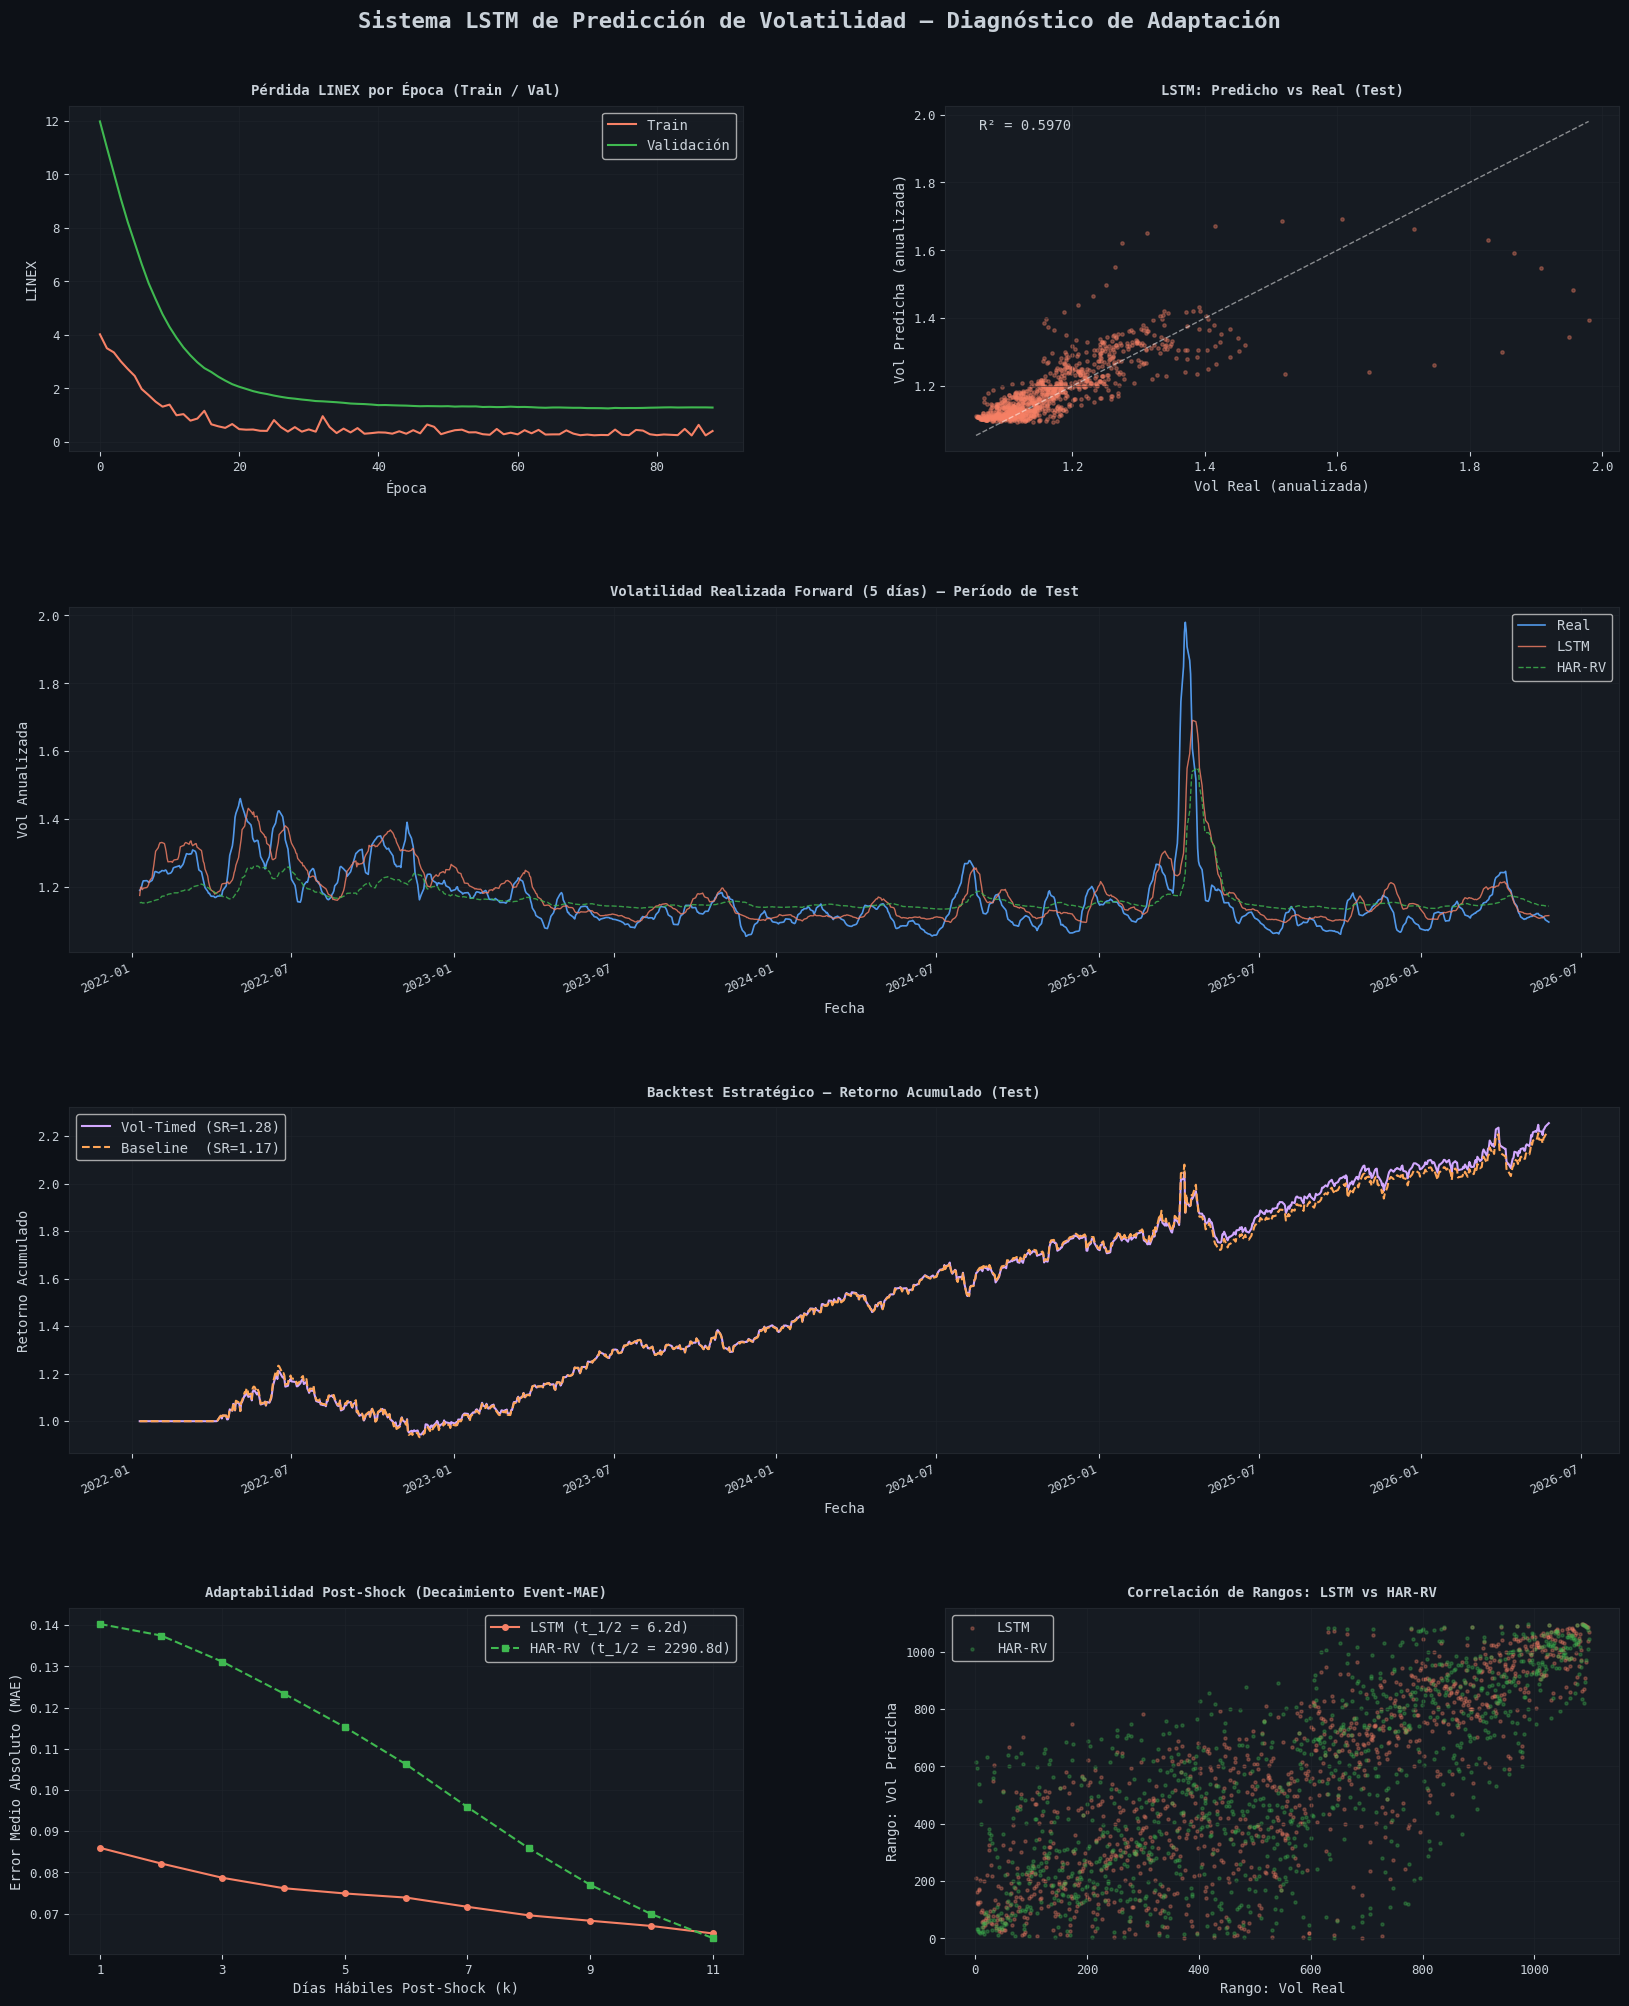

  Figura guardada → lstm_vol_report.png


In [ ]:
# ============================================================
# SECCIÓN 10: VISUALIZACIÓN DIAGNÓSTICA
# ============================================================

def generate_plots(
    y_true: np.ndarray,
    y_pred_lstm: np.ndarray,
    y_pred_har: np.ndarray,
    test_dates: pd.DatetimeIndex,
    history: dict,
    bt: dict,
    config: dict,
) -> None:
    """
    Figura diagnóstica optimizada de 6 paneles:

      [0,0] Curvas de pérdida train/val por época
      [0,1] Dispersión: predicho vs real (test set)
      [1,:] Serie temporal: real, LSTM, HAR-RV en el período de test
      [2,0] Curva de Adaptabilidad Event-MAE (con Half-Life)
      [2,1] Dispersión de rangos: LSTM vs HAR-RV
      [3,:] Curvas de equity del backtest (Alineado con fechas)
    """
    matplotlib.rcParams.update({"font.family": "monospace"})

    # Paleta de colores (tema oscuro tipo GitHub)
    BG   = "#0d1117"
    CELL = "#161b22"
    GRID = "#21262d"
    TEXT = "#c9d1d9"
    C = {
        "actual": "#58a6ff", "lstm":   "#f78166",
        "har":    "#3fb950", "volbt":  "#d2a8ff",
        "basebt": "#ffa657", "white":  "#ffffff",
    }

    fig = plt.figure(figsize=(20, 24), facecolor=BG)
    gs  = GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.3)

    def ax_style(ax, title=""):
        """Aplica el tema oscuro a un eje."""
        ax.set_facecolor(CELL)
        for side in ax.spines.values():
            side.set_color(GRID)
        ax.tick_params(colors=TEXT, labelsize=9)
        ax.xaxis.label.set_color(TEXT)
        ax.yaxis.label.set_color(TEXT)
        ax.grid(True, color=GRID, linewidth=0.5, alpha=0.7)
        if title:
            ax.set_title(title, color=TEXT, fontweight="bold", pad=8, fontsize=10)

    n  = len(y_true)
    td = test_dates[-n:] if len(test_dates) >= n else pd.RangeIndex(n)

    # --- Panel [0,0]: curvas de pérdida por época ---
    ax = fig.add_subplot(gs[0, 0])
    ax_style(ax, "Pérdida LINEX por Época (Train / Val)")
    ax.plot(history["train_loss"], color=C["lstm"], lw=1.5, label="Train")
    ax.plot(history["val_loss"],   color=C["har"],  lw=1.5, label="Validación")
    ax.set_xlabel("Época")
    ax.set_ylabel("LINEX")
    ax.legend(facecolor=CELL, labelcolor=TEXT)

    # --- Panel [0,1]: dispersión predicho vs real ---
    ax = fig.add_subplot(gs[0, 1])
    ax_style(ax, "LSTM: Predicho vs Real (Test)")
    ax.scatter(y_true, y_pred_lstm, alpha=0.35, s=6, color=C["lstm"])
    lo = min(y_true.min(), y_pred_lstm.min())
    hi = max(y_true.max(), y_pred_lstm.max())
    ax.plot([lo, hi], [lo, hi], "--", color=C["white"], lw=1.0, alpha=0.5)
    ax.text(0.05, 0.93, f"R² = {r2_score(y_true, y_pred_lstm):.4f}",
            transform=ax.transAxes, color=TEXT, fontsize=10)
    ax.set_xlabel("Vol Real (anualizada)")
    ax.set_ylabel("Vol Predicha (anualizada)")

    # --- Panel [1,:]: series temporales ---
    y_true2_log = y_te[LB : LB + n]  # Vol real sin suavizar para mostrar shocks
    y_true2 = np.exp(y_true2_log)

    ax = fig.add_subplot(gs[1, :])
    ax_style(ax, "Volatilidad Realizada Forward (5 días) — Período de Test")
    ax.plot(td, y_true,      color=C["actual"], lw=1.2, label="Real",   alpha=0.9)
    ax.plot(td, y_pred_lstm, color=C["lstm"],   lw=1.0, label="LSTM",   alpha=0.8)
    ax.plot(td, y_pred_har,  color=C["har"],    lw=1.0, label="HAR-RV", alpha=0.8, ls="--")
    # ax.plot(td, y_true2,     color=C["actual"], lw=0.8, label="Real (sin suavizar)", alpha=0.5, ls=":")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Vol Anualizada")
    ax.legend(facecolor=CELL, labelcolor=TEXT)
    if hasattr(td[0], "strftime"):
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=25, ha="right")

    # --- Panel [2,0]: Curva de Adaptabilidad Event-MAE ---
    ax = fig.add_subplot(gs[3, 0])
    ax_style(ax, "Adaptabilidad Post-Shock (Decaimiento Event-MAE)")
    
    horizon = 11
    mae_lstm, hl_lstm = calculate_adaptability(y_true, y_pred_lstm, horizon=horizon)
    mae_har, hl_har   = calculate_adaptability(y_true, y_pred_har, horizon=horizon)
    
    x_k = np.arange(1, horizon + 1)
    lbl_lstm = f"LSTM (t_1/2 = {hl_lstm:.1f}d)" if not np.isnan(hl_lstm) else "LSTM"
    lbl_har  = f"HAR-RV (t_1/2 = {hl_har:.1f}d)" if not np.isnan(hl_har) else "HAR-RV"
    
    ax.plot(x_k, mae_lstm, color=C["lstm"], marker='o', markersize=4, lw=1.5, label=lbl_lstm)
    ax.plot(x_k, mae_har,  color=C["har"],  marker='s', markersize=4, lw=1.5, ls="--", label=lbl_har)
    
    ax.set_xlabel("Días Hábiles Post-Shock (k)")
    ax.set_ylabel("Error Medio Absoluto (MAE)")
    ax.set_xticks(x_k[::2])
    ax.legend(facecolor=CELL, labelcolor=TEXT)

    # --- Panel [2,1]: correlación de rangos LSTM vs HAR ---
    ax = fig.add_subplot(gs[3, 1])
    ax_style(ax, "Correlación de Rangos: LSTM vs HAR-RV")
    rank_true = stats.rankdata(y_true)
    ax.scatter(rank_true, stats.rankdata(y_pred_lstm),
               color=C["lstm"], alpha=0.3, s=5, label="LSTM")
    ax.scatter(rank_true, stats.rankdata(y_pred_har),
               color=C["har"],  alpha=0.3, s=5, label="HAR-RV")
    ax.set_xlabel("Rango: Vol Real")
    ax.set_ylabel("Rango: Vol Predicha")
    ax.legend(facecolor=CELL, labelcolor=TEXT)

    # --- Panel [3,:]: Curvas de equity del backtest ---
    ax = fig.add_subplot(gs[2, :])
    ax_style(ax, "Backtest Estratégico — Retorno Acumulado (Test)")
    eq_vol  = np.cumprod(1.0 + bt["ret_vol"])
    eq_base = np.cumprod(1.0 + bt["ret_base"])
    
    ax.plot(td, eq_vol,  color=C["volbt"],  lw=1.5,
            label=f"Vol-Timed (SR={bt['sharpe_vol']:.2f})")
    ax.plot(td, eq_base, color=C["basebt"], lw=1.5, ls="--",
            label=f"Baseline  (SR={bt['sharpe_base']:.2f})")
    
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Retorno Acumulado")
    ax.legend(facecolor=CELL, labelcolor=TEXT)
    if hasattr(td[0], "strftime"):
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=25, ha="right")

    fig.suptitle("Sistema LSTM de Predicción de Volatilidad — Diagnóstico de Adaptación",
                 color=TEXT, fontsize=16, fontweight="bold", y=0.92)

    plt.savefig(config["plot_path"], dpi=150, bbox_inches="tight", facecolor=BG)
    plt.show()
    print(f"  Figura guardada → {config['plot_path']}")


# ── Generar figura diagnóstica ────────────────────────────────────────
print("\n[GRÁFICO] Generando figura diagnóstica...")
generate_plots(y_true, y_lstm, y_har, te_dates, history, bt, CONFIG)
